In [ ]:
# --- STEP 0: Install deps (if not already) ---
import pandas as pd
import numpy as np
from scipy.signal import resample
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.fft import fft


In [ ]:
# --- STEP 1: Load dataset ---

df = pd.read_csv("/content/drive/MyDrive/Defence/BP_Measuring_finalDataV2.csv")
display(df.head(10))

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,689666a4054bb9ca6f371a48,1,53465,53297,53166,53039,53234.0,53247.0,53156.0,53171.0,...,NaN,100,107,44,Male,180.0,98,30.246914,122,83
1,689666a4054bb9ca6f371a49,2,54755,54760,54767,54775,54782.0,54785.0,54804.0,54817.0,...,30759.0,100,125,30,Female,154.0,43,18.131219,102,68
2,689666a4054bb9ca6f371a4a,3,61920,61724,61878,61801,61611.0,61651.0,61801.0,61822.0,...,NaN,100,93,61,Female,144.0,62,29.899691,141,93
3,689666a4054bb9ca6f371a4b,4,59870,59829,59868,59922,59982.0,59954.0,59904.0,59956.0,...,NaN,98,71,45,Male,172.0,103,34.816117,139,96
4,689666a4054bb9ca6f371a4c,5,61487,61599,61710,61695,61531.0,61550.0,61506.0,61582.0,...,45313.0,98,166,23,Male,172.0,88,29.745809,112,75
5,689666a4054bb9ca6f371a4d,6,61878,62116,62117,62150,62085.0,62098.0,62093.0,62133.0,...,NaN,100,107,21,Male,165.0,68,24.977043,104,61
6,689666a4054bb9ca6f371a4e,7,55798,55766,55710,55678,55677.0,55689.0,55689.0,55698.0,...,NaN,100,136,22,Male,167.0,86,30.836531,108,80
7,689666a4054bb9ca6f371a4f,8,65781,65850,65149,65549,65698.0,65876.0,65877.0,65411.0,...,NaN,100,150,23,Male,177.0,107,34.153660,111,72
8,689666a4054bb9ca6f371a50,9,62554,2783,1136,1148,24925.0,58433.0,59563.0,60109.0,...,NaN,99,68,21,Male,182.0,100,30.189591,120,79
9,689666a4054bb9ca6f371a51,10,1024,1023,1025,1026,NaN,NaN,NaN,NaN,...,NaN,98,72,30,Male,175.0,80,26.122449,120,80


In [ ]:
# Drop the row with index 9
df = df.drop(9)

print("Row with index 9 dropped.")
print(f"New DataFrame shape: {df.shape}")

Row with index 9 dropped.
New DataFrame shape: (328, 351)


In [ ]:
display(df.head(10))

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,689666a4054bb9ca6f371a48,1,53465,53297,53166,53039,53234.0,53247.0,53156.0,53171.0,...,NaN,100,107,44,Male,180.0,98,30.246914,122,83
1,689666a4054bb9ca6f371a49,2,54755,54760,54767,54775,54782.0,54785.0,54804.0,54817.0,...,30759.0,100,125,30,Female,154.0,43,18.131219,102,68
2,689666a4054bb9ca6f371a4a,3,61920,61724,61878,61801,61611.0,61651.0,61801.0,61822.0,...,NaN,100,93,61,Female,144.0,62,29.899691,141,93
3,689666a4054bb9ca6f371a4b,4,59870,59829,59868,59922,59982.0,59954.0,59904.0,59956.0,...,NaN,98,71,45,Male,172.0,103,34.816117,139,96
4,689666a4054bb9ca6f371a4c,5,61487,61599,61710,61695,61531.0,61550.0,61506.0,61582.0,...,45313.0,98,166,23,Male,172.0,88,29.745809,112,75
5,689666a4054bb9ca6f371a4d,6,61878,62116,62117,62150,62085.0,62098.0,62093.0,62133.0,...,NaN,100,107,21,Male,165.0,68,24.977043,104,61
6,689666a4054bb9ca6f371a4e,7,55798,55766,55710,55678,55677.0,55689.0,55689.0,55698.0,...,NaN,100,136,22,Male,167.0,86,30.836531,108,80
7,689666a4054bb9ca6f371a4f,8,65781,65850,65149,65549,65698.0,65876.0,65877.0,65411.0,...,NaN,100,150,23,Male,177.0,107,34.153660,111,72
8,689666a4054bb9ca6f371a50,9,62554,2783,1136,1148,24925.0,58433.0,59563.0,60109.0,...,NaN,99,68,21,Male,182.0,100,30.189591,120,79
10,689666a4054bb9ca6f371a52,11,59696,59669,59694,59683,59732.0,59569.0,59619.0,59619.0,...,NaN,100,115,21,Male,180.0,78,24.074074,116,68


In [ ]:
# Identify entries with -999 in heartRate or spo2
error_entries = df[(df['heartRate'] == -999) | (df['spo2'] == -999)]

# Display the identified entries
display(error_entries)

# Print the number of such entries
print(f"\nNumber of entries with -999 in heartRate or spo2: {len(error_entries)}")

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
25,689666a4054bb9ca6f371a61,26,53864,53871,53839,53700,53666.0,53673.0,53704.0,53683.0,...,NaN,-999,187,22,Male,167.00,70,25.099502,116,74
53,68971b8c6af5bb099f84c693,54,52329,52255,52322,52279,52157.0,52139.0,52285.0,52321.0,...,NaN,-999,88,21,Female,160.02,55,21.480000,112,74
59,6897385157f90f6e80917148,60,56938,56954,56909,56921,56961.0,56968.0,56911.0,56969.0,...,NaN,-999,115,25,Male,170.18,76,26.240000,120,80
141,6898ce537e9100dfd3236ed0,142,52901,52895,52882,52882,52859.0,52845.0,52849.0,52845.0,...,NaN,-999,-999,22,Male,180.34,69,21.220000,108,75
149,6898d1b77e9100dfd3236ee0,150,52939,52974,52996,52782,52887.0,52967.0,52987.0,52952.0,...,NaN,-999,-999,25,Male,160.02,72,28.120000,112,71
152,6898d3087e9100dfd3236ee7,153,53179,53191,53197,53228,53194.0,53181.0,53207.0,53173.0,...,NaN,-999,187,23,Male,165.10,68,24.950000,132,83
181,6898e2e57e9100dfd3236f22,182,54833,54812,54799,54771,54762.0,54747.0,54765.0,54778.0,...,NaN,-999,-999,24,Male,165.10,56,20.540000,119,73
184,6898e4987e9100dfd3236f29,185,51377,51398,51376,51379,51340.0,51333.0,51317.0,51286.0,...,NaN,-999,-999,23,Male,177.80,58,18.350000,109,71
195,6898e9ff8b93e8da8a1e52ff,196,59047,59100,59002,59062,59058.0,59113.0,59148.0,59159.0,...,NaN,-999,-999,21,Male,182.88,85,25.410000,114,69
211,6899a52ce986f6946ce7d422,212,55206,55226,55206,55219,55208.0,55258.0,55314.0,55299.0,...,NaN,-999,65,25,Male,175.26,70,22.790000,114,77



Number of entries with -999 in heartRate or spo2: 17


In [ ]:
# Identify entries with -999 in heartRate
error_entries_HR = df[(df['heartRate'] == -999)]

# Display the identified entries
display(error_entries_HR)

# Print the number of such entries
print(f"\nNumber of entries with -999 in heartRate {len(error_entries_HR)}")

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
141,6898ce537e9100dfd3236ed0,142,52901,52895,52882,52882,52859.0,52845.0,52849.0,52845.0,...,NaN,-999,-999,22,Male,180.34,69,21.22,108,75
149,6898d1b77e9100dfd3236ee0,150,52939,52974,52996,52782,52887.0,52967.0,52987.0,52952.0,...,NaN,-999,-999,25,Male,160.02,72,28.12,112,71
181,6898e2e57e9100dfd3236f22,182,54833,54812,54799,54771,54762.0,54747.0,54765.0,54778.0,...,NaN,-999,-999,24,Male,165.10,56,20.54,119,73
184,6898e4987e9100dfd3236f29,185,51377,51398,51376,51379,51340.0,51333.0,51317.0,51286.0,...,NaN,-999,-999,23,Male,177.80,58,18.35,109,71
195,6898e9ff8b93e8da8a1e52ff,196,59047,59100,59002,59062,59058.0,59113.0,59148.0,59159.0,...,NaN,-999,-999,21,Male,182.88,85,25.41,114,69
236,6899b3b9e986f6946ce7d45a,237,54231,54219,54217,54213,54192.0,54204.0,54195.0,54202.0,...,NaN,-999,-999,21,Female,165.10,70,25.68,115,85
241,6899b6bce986f6946ce7d466,242,59814,59802,59822,59806,59809.0,59843.0,59824.0,59841.0,...,NaN,-999,-999,21,Female,165.10,70,25.68,115,85
263,689a2934a5d2fda0e473600d,264,56060,56038,56024,55973,55935.0,55935.0,55925.0,55945.0,...,NaN,-999,-999,23,Male,175.26,69,22.46,117,81
298,68a1f54485ff9a6c818171d0,299,54205,54229,54048,54205,54010.0,53190.0,53275.0,53312.0,...,NaN,-999,-999,23,Male,165.10,60,22.01,118,87
307,68a200f3d5548939d4f812be,308,46915,48095,47731,47030,47246.0,47704.0,48362.0,48664.0,...,NaN,-999,-999,24,Male,165.10,72,26.41,133,91



Number of entries with -999 in heartRate 10


In [ ]:
# Identify entries with -999 in heartRate or spo2
error_entries_SPO2 = df[(df['spo2'] == -999)]

# Display the identified entries
display(error_entries_SPO2)

# Print the number of such entries
print(f"\nNumber of entries with -999 in or spo2: {len(error_entries_SPO2)}")

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
25,689666a4054bb9ca6f371a61,26,53864,53871,53839,53700,53666.0,53673.0,53704.0,53683.0,...,NaN,-999,187,22,Male,167.00,70,25.099502,116,74
53,68971b8c6af5bb099f84c693,54,52329,52255,52322,52279,52157.0,52139.0,52285.0,52321.0,...,NaN,-999,88,21,Female,160.02,55,21.480000,112,74
59,6897385157f90f6e80917148,60,56938,56954,56909,56921,56961.0,56968.0,56911.0,56969.0,...,NaN,-999,115,25,Male,170.18,76,26.240000,120,80
141,6898ce537e9100dfd3236ed0,142,52901,52895,52882,52882,52859.0,52845.0,52849.0,52845.0,...,NaN,-999,-999,22,Male,180.34,69,21.220000,108,75
149,6898d1b77e9100dfd3236ee0,150,52939,52974,52996,52782,52887.0,52967.0,52987.0,52952.0,...,NaN,-999,-999,25,Male,160.02,72,28.120000,112,71
152,6898d3087e9100dfd3236ee7,153,53179,53191,53197,53228,53194.0,53181.0,53207.0,53173.0,...,NaN,-999,187,23,Male,165.10,68,24.950000,132,83
181,6898e2e57e9100dfd3236f22,182,54833,54812,54799,54771,54762.0,54747.0,54765.0,54778.0,...,NaN,-999,-999,24,Male,165.10,56,20.540000,119,73
184,6898e4987e9100dfd3236f29,185,51377,51398,51376,51379,51340.0,51333.0,51317.0,51286.0,...,NaN,-999,-999,23,Male,177.80,58,18.350000,109,71
195,6898e9ff8b93e8da8a1e52ff,196,59047,59100,59002,59062,59058.0,59113.0,59148.0,59159.0,...,NaN,-999,-999,21,Male,182.88,85,25.410000,114,69
211,6899a52ce986f6946ce7d422,212,55206,55226,55206,55219,55208.0,55258.0,55314.0,55299.0,...,NaN,-999,65,25,Male,175.26,70,22.790000,114,77



Number of entries with -999 in or spo2: 17


In [ ]:
# Identify entries with spo2 less than 75% and heartRate less than 50
low_vitals_entries = df[(df['spo2'] < 80)]

# Display the identified entries
print("Entries with spo2 < 80%")
display(low_vitals_entries)

# Print the number of such entries
print(f"\nNumber of entries with spo2 < 80% {len(low_vitals_entries)}")

Entries with spo2 < 80%


,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
14,689666a4054bb9ca6f371a56,15,64927,64887,65058,65135,65135.0,65144.0,65033.0,65024.0,...,NaN,29,125,20,Male,162.00,63,24.005487,90,66
21,689666a4054bb9ca6f371a5d,22,58572,58605,58740,58810,58769.0,58645.0,58559.0,58589.0,...,NaN,51,71,22,Male,170.00,72,24.913495,151,81
25,689666a4054bb9ca6f371a61,26,53864,53871,53839,53700,53666.0,53673.0,53704.0,53683.0,...,NaN,-999,187,22,Male,167.00,70,25.099502,116,74
26,689666a4054bb9ca6f371a62,27,54786,54781,54896,54936,54974.0,54954.0,55021.0,55044.0,...,NaN,76,75,22,Male,167.00,70,25.099502,116,74
53,68971b8c6af5bb099f84c693,54,52329,52255,52322,52279,52157.0,52139.0,52285.0,52321.0,...,NaN,-999,88,21,Female,160.02,55,21.480000,112,74
56,68973056fdad67d66e5f2c03,57,59109,59134,59024,59020,59104.0,59088.0,59110.0,59083.0,...,NaN,58,107,22,Male,167.64,65,23.130000,100,66
59,6897385157f90f6e80917148,60,56938,56954,56909,56921,56961.0,56968.0,56911.0,56969.0,...,NaN,-999,115,25,Male,170.18,76,26.240000,120,80
66,68973cd9f077907221199206,67,56054,56063,56044,56060,56056.0,56047.0,56073.0,56075.0,...,NaN,72,214,22,Male,172.72,74,24.810000,141,81
91,68979520341377cae496fbf1,92,51691,51713,51515,51569,51567.0,51465.0,51549.0,51529.0,...,NaN,75,93,21,Male,172.72,64,21.450000,114,84
118,6898b131663f697566990966,119,59568,59534,59551,59499,59504.0,59548.0,59530.0,59509.0,...,NaN,75,187,21,Male,175.26,85,27.670000,139,103



Number of entries with spo2 < 80% 37


In [ ]:
# Identify entries with spo2 less than 75% and heartRate less than 50
low_vitals_entries = df[(df['heartRate'] < 50)]

# Display the identified entries
print("Entries with and heartRate < 50:")
display(low_vitals_entries)

# Print the number of such entries
print(f"\nNumber of entries with heartRate < 50: {len(low_vitals_entries)}")

Entries with and heartRate < 50:


,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
141,6898ce537e9100dfd3236ed0,142,52901,52895,52882,52882,52859.0,52845.0,52849.0,52845.0,...,NaN,-999,-999,22,Male,180.34,69,21.22,108,75
149,6898d1b77e9100dfd3236ee0,150,52939,52974,52996,52782,52887.0,52967.0,52987.0,52952.0,...,NaN,-999,-999,25,Male,160.02,72,28.12,112,71
181,6898e2e57e9100dfd3236f22,182,54833,54812,54799,54771,54762.0,54747.0,54765.0,54778.0,...,NaN,-999,-999,24,Male,165.10,56,20.54,119,73
184,6898e4987e9100dfd3236f29,185,51377,51398,51376,51379,51340.0,51333.0,51317.0,51286.0,...,NaN,-999,-999,23,Male,177.80,58,18.35,109,71
195,6898e9ff8b93e8da8a1e52ff,196,59047,59100,59002,59062,59058.0,59113.0,59148.0,59159.0,...,NaN,-999,-999,21,Male,182.88,85,25.41,114,69
218,6899a921e986f6946ce7d432,219,58574,58394,58372,58441,58415.0,58306.0,58316.0,58348.0,...,NaN,99,48,25,Male,165.10,72,26.41,118,84
220,6899aa06e986f6946ce7d436,221,54206,54328,54274,54246,54403.0,54357.0,54302.0,54343.0,...,NaN,99,48,23,Female,172.72,65,21.79,107,76
221,6899aa16e986f6946ce7d437,222,54206,54328,54274,54246,54403.0,54357.0,54302.0,54343.0,...,NaN,99,48,23,Female,172.72,65,21.79,107,76
236,6899b3b9e986f6946ce7d45a,237,54231,54219,54217,54213,54192.0,54204.0,54195.0,54202.0,...,NaN,-999,-999,21,Female,165.10,70,25.68,115,85
241,6899b6bce986f6946ce7d466,242,59814,59802,59822,59806,59809.0,59843.0,59824.0,59841.0,...,NaN,-999,-999,21,Female,165.10,70,25.68,115,85



Number of entries with heartRate < 50: 17


In [ ]:
# Identify entries with spo2 less than 75% and heartRate less than 50
low_vitals_entries = df[(df['spo2'] < 80) | (df['heartRate'] < 50) ]

# Display the identified entries
print("Entries with spo2 < 80% and or heartRate < 50")
display(low_vitals_entries)

# Print the number of such entries
print(f"\nNumber of entries with spo2 < 80% and or heartRate < 50: {len(low_vitals_entries)}")

Entries with spo2 < 80% and or heartRate < 50


,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP



Number of entries with spo2 < 80% and or heartRate < 50: 0


In [ ]:
# Impute `spo2` values:
# Replace -999 and values < 80 with NaN
df['spo2'] = df['spo2'].replace(-999, np.nan)
df['spo2'] = df['spo2'].where(df['spo2'] >= 80, np.nan)  # Replace values below 80 with NaN
spo2_median = df['spo2'].median()  # Get the median
df['spo2'].fillna(spo2_median, inplace=True)  # Impute missing values with the median

# Impute `heartRate` values:
# Replace -999 and values < 45 with NaN
df['heartRate'] = df['heartRate'].replace(-999, np.nan)
df['heartRate'] = df['heartRate'].where(df['heartRate'] >= 50, np.nan)  # Replace values below 45 with NaN
heartRate_mean = df['heartRate'].mean()  # Get the mean
df['heartRate'].fillna(heartRate_mean, inplace=True)  # Impute missing values with the mean

# Check the data after imputation
print(df[['spo2', 'heartRate']].describe())


             spo2   heartRate
count  328.000000  328.000000
mean    97.106707  140.926045
std      4.305343   44.097241
min     80.000000   50.000000
25%     96.750000  107.000000
50%     99.000000  140.926045
75%    100.000000  166.000000
max    100.000000  300.000000


/tmp/ipython-input-2736165181.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['spo2'].fillna(spo2_median, inplace=True)  # Impute missing values with the median
/tmp/ipython-input-2736165181.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [ ]:
# Identify entries with spo2 less than 75% and heartRate less than 50
high_vitals_entries = df[ (df['heartRate'] >= 200) ]

# Display the identified entries
print("Entries with heartRate => 50")
display(high_vitals_entries)

# Print the number of such entries
print(f"\nNumber of entries heartRate => 50: {len(high_vitals_entries)}")

Entries with heartRate => 50


,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
12,689666a4054bb9ca6f371a54,13,66466,66424,66429,66419,66420.0,66444.0,66415.0,66472.0,...,NaN,99.0,250.0,21,Female,165.00,49,17.998163,110,78
13,689666a4054bb9ca6f371a55,14,67309,67167,67002,67128,67186.0,67090.0,67016.0,66997.0,...,NaN,95.0,214.0,24,Male,172.00,60,20.281233,105,80
15,689666a4054bb9ca6f371a57,16,63208,63242,63070,63053,63202.0,63283.0,63379.0,63264.0,...,NaN,88.0,250.0,20,Male,172.00,54,18.253110,123,82
66,68973cd9f077907221199206,67,56054,56063,56044,56060,56056.0,56047.0,56073.0,56075.0,...,NaN,99.0,214.0,22,Male,172.72,74,24.810000,141,81
74,689747cf48323f172b3fd599,75,58665,58626,58626,58649,58602.0,58593.0,58581.0,58565.0,...,NaN,82.0,214.0,27,Male,172.72,89,29.830000,116,73
75,6897486548323f172b3fd59b,76,62058,62147,62312,62497,62612.0,62574.0,62459.0,62594.0,...,NaN,95.0,250.0,19,Male,175.26,64,20.840000,108,67
109,6898642c439b265a0f852ac0,110,57606,57589,57349,57344,57447.0,57213.0,57161.0,57188.0,...,NaN,99.0,214.0,25,Male,172.72,80,26.820000,118,86
110,68986491439b265a0f852ac2,111,57124,57128,57090,57006,56928.0,56899.0,56882.0,56786.0,...,NaN,81.0,214.0,26,Male,177.80,86,27.200000,132,84
111,68986536439b265a0f852ac5,112,55072,54944,55222,55174,54911.0,55086.0,55700.0,55598.0,...,NaN,96.0,214.0,24,Male,167.64,75,26.690000,107,63
112,68986541439b265a0f852ac6,113,55072,54944,55222,55174,54911.0,55086.0,55700.0,55598.0,...,NaN,96.0,214.0,24,Male,167.64,75,26.690000,107,63



Number of entries heartRate => 50: 30


In [ ]:
# Replace heartRate values above a certain threshold (e.g., 200 bpm) with NaN
df['heartRate'] = df['heartRate'].replace(-999, np.nan)  # Replace -999 with NaN if not already done
df['heartRate'] = df['heartRate'].where(df['heartRate'] < 200, np.nan)  # Replace extreme heart rate with NaN

# Now impute these NaN values with the mean or median
heartRate_median = df['heartRate'].median()  # Get the median of heart rate
df['heartRate'].fillna(heartRate_median, inplace=True)  # Impute with the median

# Check the data after imputation
print(df['heartRate'].describe())


count    328.000000
mean     132.389460
std       33.185454
min       50.000000
25%      107.000000
50%      136.000000
75%      150.000000
max      187.000000
Name: heartRate, dtype: float64


/tmp/ipython-input-1209852446.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['heartRate'].fillna(heartRate_median, inplace=True)  # Impute with the median


In [ ]:
# Calculate the median for both 'heartRate' and 'spo2' columns
heart_rate_median = df['heartRate'].median()
spo2_median = df['spo2'].median()

print(f"Median heartRate: {heart_rate_median}")
print(f"Median spo2: {spo2_median}")


Median heartRate: 136.0
Median spo2: 99.0


In [ ]:
# Save the DataFrame to a CSV file
output_path = "df_with_nulls.csv" # You can change the filename
df.to_csv(output_path, index=False)

print(f"DataFrame saved to '{output_path}'")

DataFrame saved to 'df_with_nulls.csv'


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Label encode the gender column
df['userGender'] = le.fit_transform(df['userGender'])

# Check the result
print(df['userGender'].head())

# Optionally, check the mapping of labels to values
print(le.classes_)  # This will print the unique categories mapped to 0, 1, 2, etc.


0    1
1    0
2    0
3    1
4    1
Name: userGender, dtype: int64
['Female' 'Male']


In [ ]:
display(df.head(15))

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,689666a4054bb9ca6f371a48,1,53465,53297,53166,53039,53234.0,53247.0,53156.0,53171.0,...,NaN,100.0,107.0,44,1,180.0,98,30.246914,122,83
1,689666a4054bb9ca6f371a49,2,54755,54760,54767,54775,54782.0,54785.0,54804.0,54817.0,...,30759.0,100.0,125.0,30,0,154.0,43,18.131219,102,68
2,689666a4054bb9ca6f371a4a,3,61920,61724,61878,61801,61611.0,61651.0,61801.0,61822.0,...,NaN,100.0,93.0,61,0,144.0,62,29.899691,141,93
3,689666a4054bb9ca6f371a4b,4,59870,59829,59868,59922,59982.0,59954.0,59904.0,59956.0,...,NaN,98.0,71.0,45,1,172.0,103,34.816117,139,96
4,689666a4054bb9ca6f371a4c,5,61487,61599,61710,61695,61531.0,61550.0,61506.0,61582.0,...,45313.0,98.0,166.0,23,1,172.0,88,29.745809,112,75
5,689666a4054bb9ca6f371a4d,6,61878,62116,62117,62150,62085.0,62098.0,62093.0,62133.0,...,NaN,100.0,107.0,21,1,165.0,68,24.977043,104,61
6,689666a4054bb9ca6f371a4e,7,55798,55766,55710,55678,55677.0,55689.0,55689.0,55698.0,...,NaN,100.0,136.0,22,1,167.0,86,30.836531,108,80
7,689666a4054bb9ca6f371a4f,8,65781,65850,65149,65549,65698.0,65876.0,65877.0,65411.0,...,NaN,100.0,150.0,23,1,177.0,107,34.153660,111,72
8,689666a4054bb9ca6f371a50,9,62554,2783,1136,1148,24925.0,58433.0,59563.0,60109.0,...,NaN,99.0,68.0,21,1,182.0,100,30.189591,120,79
10,689666a4054bb9ca6f371a52,11,59696,59669,59694,59683,59732.0,59569.0,59619.0,59619.0,...,NaN,100.0,115.0,21,1,180.0,78,24.074074,116,68


In [ ]:
df = df.drop(columns=['_id', 'serialNumber'])

# To verify
print(df.head())


   ir[0]  ir[1]  ir[2]  ir[3]    ir[4]    ir[5]    ir[6]    ir[7]    ir[8]  \
0  53465  53297  53166  53039  53234.0  53247.0  53156.0  53171.0  53147.0   
1  54755  54760  54767  54775  54782.0  54785.0  54804.0  54817.0  54858.0   
2  61920  61724  61878  61801  61611.0  61651.0  61801.0  61822.0  61699.0   
3  59870  59829  59868  59922  59982.0  59954.0  59904.0  59956.0  59963.0   
4  61487  61599  61710  61695  61531.0  61550.0  61506.0  61582.0  61451.0   

     ir[9]  ...  red[169]   spo2  heartRate  userAge  userGender  userHeight  \
0  53255.0  ...       NaN  100.0      107.0       44           1       180.0   
1  54864.0  ...   30759.0  100.0      125.0       30           0       154.0   
2  61829.0  ...       NaN  100.0       93.0       61           0       144.0   
3  59986.0  ...       NaN   98.0       71.0       45           1       172.0   
4  61508.0  ...   45313.0   98.0      166.0       23           1       172.0   

   userWeight    userBmi  systolic_BP  diastolic_B

In [ ]:
# Find the correlation matrix
correlation_matrix = df.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix.head())

Correlation Matrix (first 5 rows and columns):


,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],ir[8],ir[9],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
ir[0],1.000000,0.775795,0.767899,0.770550,0.894643,0.994791,0.994068,0.991159,0.991925,0.988603,...,0.840870,-0.018963,-0.003437,-0.093575,-0.065035,0.018351,-0.077011,-0.101501,-0.046574,-0.038206
ir[1],0.775795,1.000000,0.999032,0.998462,0.972847,0.806781,0.797269,0.791435,0.792476,0.785740,...,0.838722,-0.031019,0.068069,-0.065106,-0.066637,-0.033772,-0.142493,-0.139801,-0.040151,-0.031700
ir[2],0.767899,0.999032,1.000000,0.999417,0.970848,0.800408,0.791322,0.784687,0.785795,0.778533,...,0.829583,-0.032759,0.068309,-0.062867,-0.065939,-0.035920,-0.142794,-0.139236,-0.036705,-0.028112
ir[3],0.770550,0.998462,0.999417,1.000000,0.972779,0.803815,0.794582,0.787668,0.789184,0.782118,...,0.831019,-0.030881,0.069309,-0.061611,-0.067137,-0.035531,-0.141683,-0.138301,-0.035582,-0.025590
ir[4],0.894643,0.972847,0.970848,0.972779,1.000000,0.918055,0.911491,0.905418,0.906926,0.901211,...,0.838401,-0.027078,0.049726,-0.078956,-0.072543,-0.020846,-0.128008,-0.132989,-0.044083,-0.032596


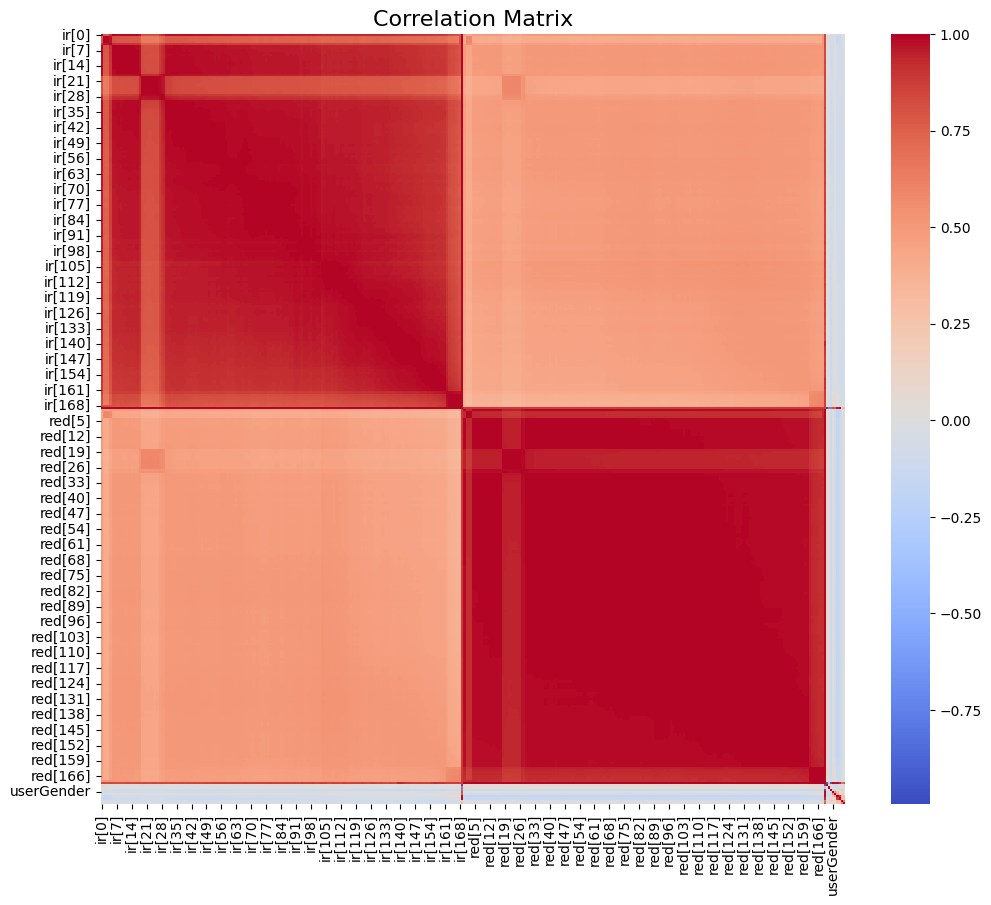

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=16)
plt.show()

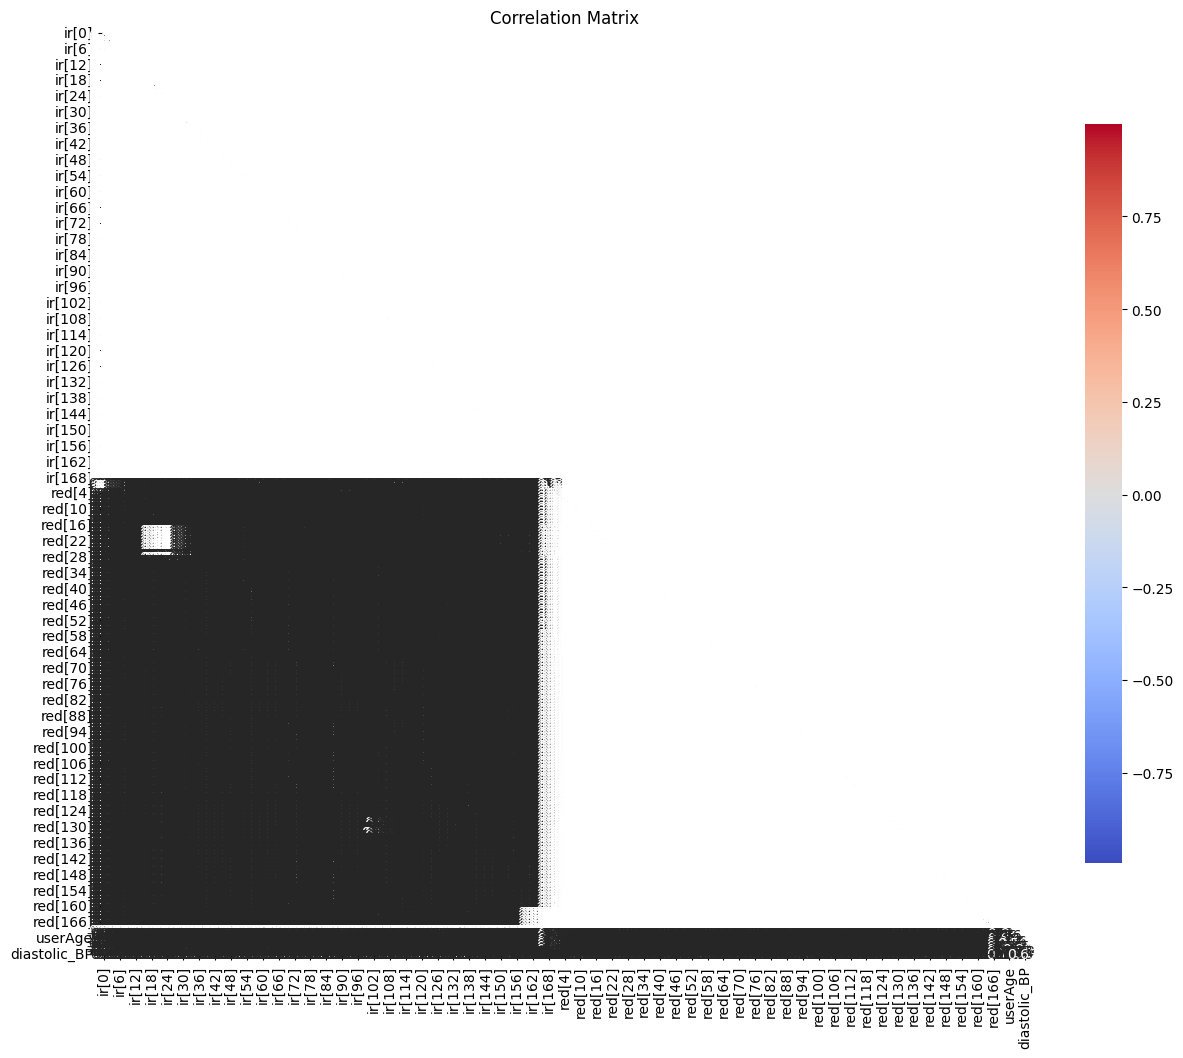

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mask the upper triangle of the correlation matrix for better readability
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.show()


In [ ]:
print(f"New DataFrame shape: {df.shape}")

New DataFrame shape: (328, 349)


In [ ]:
# Check for duplicate rows in df_limited
duplicate_rows = df[df.duplicated()]

# Display duplicate rows
display(duplicate_rows)

# Print the number of duplicate rows
print(f"\nNumber of duplicate entries in df_limited: {len(duplicate_rows)}")

,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],ir[8],ir[9],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
112,55072,54944,55222,55174,54911.0,55086.0,55700.0,55598.0,55278.0,55090.0,...,NaN,96.0,136.000000,24,1,167.64,75,26.69,107,63
146,56031,56093,56053,55953,55940.0,55911.0,55902.0,55896.0,55809.0,55699.0,...,NaN,89.0,150.000000,25,1,180.34,82,25.21,108,70
154,54717,54334,54519,54577,54714.0,54793.0,54670.0,54483.0,54571.0,54654.0,...,NaN,100.0,107.000000,23,1,180.34,54,16.60,115,80
189,53802,53850,53569,53625,53686.0,53786.0,53580.0,53408.0,53432.0,53458.0,...,NaN,92.0,150.000000,23,1,175.26,48,15.63,113,61
221,54206,54328,54274,54246,54403.0,54357.0,54302.0,54343.0,54277.0,54230.0,...,NaN,99.0,140.926045,23,0,172.72,65,21.79,107,76
235,51965,52070,51590,51714,51848.0,51991.0,51552.0,51699.0,51841.0,52036.0,...,NaN,100.0,150.000000,22,0,154.94,55,22.91,107,74
245,47397,47427,47574,47806,48133.0,48225.0,48127.0,48096.0,47973.0,47932.0,...,NaN,100.0,150.000000,22,0,154.94,56,23.33,110,78
249,49065,49049,48969,49039,49025.0,49084.0,49121.0,49045.0,49083.0,49095.0,...,NaN,99.0,166.000000,48,0,152.40,58,24.97,119,70
252,52322,52396,52220,52171,52252.0,52279.0,52215.0,52104.0,52155.0,52127.0,...,NaN,99.0,150.000000,47,0,160.02,69,26.95,127,86
259,57870,57955,58018,58083,58139.0,58269.0,58984.0,59231.0,58514.0,57675.0,...,NaN,100.0,166.000000,36,0,157.48,50,20.16,133,71



Number of duplicate entries in df_limited: 11


In [ ]:
# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Check the number of rows after dropping duplicates
print(f"Rows after removing duplicates: {df_cleaned.shape[0]}")


Rows after removing duplicates: 317


In [ ]:
# Check for duplicate rows in df_limited
duplicate_rows = df_cleaned[df_cleaned.duplicated()]

# Display duplicate rows
display(duplicate_rows)

# Print the number of duplicate rows
print(f"\nNumber of duplicate entries in df_limited: {len(duplicate_rows)}")

,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],ir[8],ir[9],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP



Number of duplicate entries in df_limited: 0


In [ ]:

# --- STEP 3: Identify IR and RED columns ---
ir_cols = [c for c in df_cleaned.columns if c.startswith("ir[")]
red_cols = [c for c in df_cleaned.columns if c.startswith("red[")]

In [ ]:
# --- STEP 3.1: Check the number of non-null values in IR and RED arrays ---

# Get the number of non-null values for each row in IR columns
ir_counts = df_cleaned[ir_cols].notna().sum(axis=1)

# Get the number of non-null values for each row in RED columns
red_counts = df_cleaned[red_cols].notna().sum(axis=1)

# Find the minimum and maximum counts for IR
min_ir_count = ir_counts.min()
max_ir_count = ir_counts.max()

# Find the minimum and maximum counts for RED
min_red_count = red_counts.min()
max_red_count = red_counts.max()

print(f"Minimum number of non-null values in IR arrays: {min_ir_count}")
print(f"Maximum number of non-null values in IR arrays: {max_ir_count}")
print(f"Minimum number of non-null values in RED arrays: {min_red_count}")
print(f"Maximum number of non-null values in RED arrays: {max_red_count}")

Minimum number of non-null values in IR arrays: 113
Maximum number of non-null values in IR arrays: 170
Minimum number of non-null values in RED arrays: 113
Maximum number of non-null values in RED arrays: 170


In [ ]:
# --- STEP 4: Function to resample waveform to fixed length ---
def resample_to_fixed_length(row, cols, target_len=200):
    arr = row[cols].to_numpy(dtype=float)
    # Remove NaNs before resampling (shorten series if needed)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.full(target_len, np.nan)  # empty signal
    return resample(arr, target_len)


In [ ]:
# --- STEP 5: Apply resampling to IR and RED ---
target_length = 200
ir_resampled = np.vstack(df_cleaned.apply(lambda row: resample_to_fixed_length(row, ir_cols, target_length), axis=1))
red_resampled = np.vstack(df_cleaned.apply(lambda row: resample_to_fixed_length(row, red_cols, target_length), axis=1))

In [ ]:
# --- STEP 6: Save resampled signals into DataFrame ---
ir_df = pd.DataFrame(ir_resampled, columns=[f"ir_{i}" for i in range(target_length)])
red_df = pd.DataFrame(red_resampled, columns=[f"red_{i}" for i in range(target_length)])

In [ ]:
# --- STEP 7: Merge back with meta + labels ---
keep_cols = ['spo2', 'heartRate', 'userAge', 'userGender', 'userHeight', 'userWeight', 'userBmi', 'systolic_BP', 'diastolic_BP']
df_clean = pd.concat([df_cleaned[keep_cols].reset_index(drop=True), ir_df, red_df], axis=1)

In [ ]:
# --- STEP 8: Save cleaned dataset ---
output_path = "/content/bp_dataset_resampledV2.csv"
df_clean.to_csv(output_path, index=False)
print(f"✅ Cleaned & resampled dataset saved to: {output_path}")
print(f"Shape: {df_clean.shape}")


✅ Cleaned & resampled dataset saved to: /content/bp_dataset_resampledV2.csv
Shape: (317, 409)


In [ ]:
display(df_clean.head())

,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,red_190,red_191,red_192,red_193,red_194,red_195,red_196,red_197,red_198,red_199
0,100.0,107.0,44,1,180.0,98,30.246914,122,83,53465.0,...,27273.118598,27284.864828,27238.849462,27305.232194,27289.679810,27243.852603,27283.764741,27269.051700,27225.870816,27214.390034
1,100.0,125.0,30,0,154.0,43,18.131219,102,68,54755.0,...,30849.143333,30769.175435,30814.321042,30766.920469,30744.651786,30805.381260,30786.732599,30850.532347,30755.787616,30799.954928
2,100.0,93.0,61,0,144.0,62,29.899691,141,93,61920.0,...,44723.357747,44687.385179,44752.517717,44723.396119,44683.442669,44709.866599,44697.651598,44764.138740,44684.514943,44734.477694
3,98.0,71.0,45,1,172.0,103,34.816117,139,96,59870.0,...,38796.905896,38803.597493,38781.293654,38783.916183,38796.831129,38806.214866,38822.492875,38788.759159,38788.628134,38766.401531
4,98.0,166.0,23,1,172.0,88,29.745809,112,75,61487.0,...,45363.027161,45331.427991,45325.212267,45321.077108,45340.601187,45361.981611,45325.363942,45355.593678,45231.186328,45388.795779


In [ ]:
# --- Step 1: Extract the relevant columns for IR and RED signals ---
ir_cols = [c for c in df_clean.columns if c.startswith("ir_")]
red_cols = [c for c in df_clean.columns if c.startswith("red_")]


In [ ]:
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks
from scipy.fft import fft

In [ ]:
# --- Function to extract time-domain and frequency-domain features from a signal ---
def extract_features(signal):
    # Ensure the signal is a float numpy array
    signal = np.asarray(signal, dtype=float)

    # Handle cases with all NaN values after conversion
    if np.all(np.isnan(signal)):
        # Return a list of NaNs for all features if the signal is all NaNs
        return [np.nan] * 14 # 14 is the number of features being extracted

    # Time-domain features
    mean_signal = np.nanmean(signal) # Use nanmean to ignore NaNs
    median_signal = np.nanmedian(signal) # Use nanmedian to ignore NaNs
    std_signal = np.nanstd(signal) # Use nanstd to ignore NaNs
    min_signal = np.nanmin(signal) if not np.all(np.isnan(signal)) else np.nan # Handle min/max on all NaNs
    max_signal = np.nanmax(signal) if not np.all(np.isnan(signal)) else np.nan # Handle min/max on all NaNs
    range_signal = max_signal - min_signal if not np.all(np.isnan(signal)) else np.nan # Handle range on all NaNs

    # SciPy stats functions handle NaNs with nan_policy='omit' or 'propagate'
    # Let's ensure we handle potential NaNs explicitly or rely on default nan_policy
    skewness_signal = skew(signal, nan_policy='omit') if len(signal[~np.isnan(signal)]) > 1 else np.nan # Need at least 2 non-NaN for skew
    kurtosis_signal = kurtosis(signal, nan_policy='omit') if len(signal[~np.isnan(signal)]) > 3 else np.nan # Need at least 4 non-NaN for kurtosis


    # Peak features (find peaks in the signal) - find_peaks requires non-NaN input
    non_nan_signal = signal[~np.isnan(signal)]
    peaks, _ = find_peaks(non_nan_signal)
    num_peaks = len(peaks)
    mean_peak_amplitude = np.nanmean(non_nan_signal[peaks]) if num_peaks > 0 else np.nan # Use nanmean

    # Frequency-domain features using FFT - fft requires non-NaN input
    if len(non_nan_signal) == 0:
         return [np.nan] * 14 # Return NaNs if no non-NaN data for FFT

    fft_values = fft(non_nan_signal)
    fft_freq = np.fft.fftfreq(len(non_nan_signal))
    fft_magnitude = np.abs(fft_values)

    # Extract dominant frequency (proxy for heart rate)
    # Need to handle case where all magnitudes are zero (e.g., constant signal)
    if np.all(fft_magnitude[1:] == 0):
         dominant_freq = np.nan
    else:
        dominant_freq = np.abs(fft_freq[np.argmax(fft_magnitude[1:]) + 1])  # Skip zero frequency (DC component)


    # Total spectral energy
    total_energy = np.sum(fft_magnitude**2)

    # Low/High Frequency Band power - ensure frequency bounds are within fft_freq range
    low_freq_indices = np.where((fft_freq >= 0.5) & (fft_freq <= 3))[0]
    high_freq_indices = np.where((fft_freq >= 3) & (fft_freq <= 6))[0]

    low_freq_band = np.sum(fft_magnitude[low_freq_indices])
    high_freq_band = np.sum(fft_magnitude[high_freq_indices])


    return [
        mean_signal, median_signal, std_signal, min_signal, max_signal, range_signal,
        skewness_signal, kurtosis_signal, num_peaks, mean_peak_amplitude,
        dominant_freq, total_energy, low_freq_band, high_freq_band
    ]

In [ ]:
# --- Extract features for both IR and Red signals ---
def extract_features_from_df(df, ir_columns, red_columns):
    features = []
    for i, row in df_clean.iterrows():
        # Extract IR and Red signal features
        ir_signal = row[ir_columns].values
        red_signal = row[red_columns].values

        ir_features = extract_features(ir_signal)
        red_features = extract_features(red_signal)

        # Combine IR and Red features into one set
        combined_features = ir_features + red_features

        # Append demographics
        demographics = [
            row['userAge'], row['userGender'], row['userHeight'], row['userWeight'],
            row['userBmi'], row['heartRate'], row['spo2']  # Assuming these columns are present
        ]

        features.append(combined_features + demographics)

    return np.array(features)


In [ ]:
# --- Prepare feature matrix and labels ---
X = extract_features_from_df(df_clean, ir_cols, red_cols)


In [ ]:
# --- Labels (systolic_BP, diastolic_BP) ---
y = df_clean[['systolic_BP', 'diastolic_BP']].values

In [ ]:
# --- Create a DataFrame for the features ---
columns = [
    'ir_mean', 'ir_median', 'ir_std', 'ir_min', 'ir_max', 'ir_range', 'ir_skewness', 'ir_kurtosis',
    'ir_num_peaks', 'ir_mean_peak_amplitude', 'ir_dominant_freq', 'ir_total_energy', 'ir_low_freq_band', 'ir_high_freq_band',
    'red_mean', 'red_median', 'red_std', 'red_min', 'red_max', 'red_range', 'red_skewness', 'red_kurtosis',
    'red_num_peaks', 'red_mean_peak_amplitude', 'red_dominant_freq', 'red_total_energy', 'red_low_freq_band', 'red_high_freq_band',
    'userAge', 'userGender', 'userHeight', 'userWeight', 'userBmi', 'heartRate', 'spo2'
]

In [ ]:
X_df = pd.DataFrame(X, columns=columns)

In [ ]:
display(X_df.head())

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_total_energy,red_low_freq_band,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,2.982998e+13,0.0,0.0,44.0,1.0,180.0,98.0,30.246914,107.0,100.0
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,3.837467e+13,0.0,0.0,30.0,0.0,154.0,43.0,18.131219,125.0,100.0
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,8.062040e+13,0.0,0.0,61.0,0.0,144.0,62.0,29.899691,93.0,100.0
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,6.006732e+13,0.0,0.0,45.0,1.0,172.0,103.0,34.816117,71.0,98.0
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,8.233843e+13,0.0,0.0,23.0,1.0,172.0,88.0,29.745809,166.0,98.0


In [ ]:
print(f"Shape of features: {X_df.shape}")
print(f"Shape of labels: {y.shape}")

Shape of features: (317, 35)
Shape of labels: (317, 2)


In [ ]:
# --- Step 1: Extract the relevant columns for IR and RED signals ---
ir_cols = [c for c in df_clean.columns if c.startswith("ir_")]
red_cols = [c for c in df_clean.columns if c.startswith("red_")]

# --- Step 2: Prepare the demographic and vitals data ---
demographics_vitals_cols = ['userAge', 'userGender', 'userHeight', 'userWeight', 'userBmi', 'spo2', 'heartRate']

# --- Step 3: Dataset with all features (IR + RED + Demographics + Vitals) ---
all_features_df = df_clean[ir_cols + red_cols + demographics_vitals_cols + ['systolic_BP', 'diastolic_BP']]

# --- Step 4: Dataset with only IR features (IR + Demographics + Vitals) ---
ir_features_df = df_clean[ir_cols + demographics_vitals_cols + ['systolic_BP', 'diastolic_BP']]

# --- Step 5: Dataset with only RED features (RED + Demographics + Vitals) ---
red_features_df = df_clean[red_cols + demographics_vitals_cols + ['systolic_BP', 'diastolic_BP']]

# --- Step 6: Variations based on excluding Demographics and Vitals ---
# Without Demographics (IR + RED + Vitals)
ir_red_vitals_df = df_clean[ir_cols + red_cols + ['spo2', 'heartRate', 'systolic_BP', 'diastolic_BP']]

# Without Vitals (IR + RED + Demographics)
ir_red_demographics_df = df_clean[ir_cols + red_cols + ['userAge', 'userGender', 'userHeight', 'userWeight', 'userBmi', 'systolic_BP', 'diastolic_BP']]

# --- Step 7: Dataset with features only (IR + RED features) ---
features_only_df = df_clean[ir_cols + red_cols + ['systolic_BP', 'diastolic_BP']]

# --- Optional: Print the first few rows of each dataset to verify ---
print("All Features Dataset:")
print(all_features_df.head() )
print(all_features_df.shape )

print("\nIR Features Dataset:")
print(ir_features_df.head())
print(ir_features_df.shape)

print("\nRED Features Dataset:")
print(red_features_df.head())
print(red_features_df.shape)

print("\nIR + RED + Vitals Dataset:")
print(ir_red_vitals_df.head())
print(ir_red_vitals_df.shape)

print("\nIR + RED + Demographics Dataset:")
print(ir_red_demographics_df.head())
print(ir_red_demographics_df.shape)

print("\nFeatures Only Dataset:")
print(features_only_df.head())
print(features_only_df.shape)


All Features Dataset:
      ir_0          ir_1          ir_2          ir_3          ir_4  \
0  53465.0  53481.287901  53021.544629  53244.859817  52954.341763   
1  54755.0  54768.967582  54754.084952  54779.760326  54772.960354   
2  61920.0  61786.696546  61759.189170  61941.177431  61670.940674   
3  59870.0  59800.345442  59884.688072  59866.951544  59968.040641   
4  61487.0  61629.954266  61622.378291  61786.899002  61579.677525   

           ir_5          ir_6          ir_7          ir_8          ir_9  ...  \
0  53349.005086  53214.617773  53132.632771  53228.182843  53078.393504  ...   
1  54785.153243  54785.423782  54802.864122  54813.767489  54842.085751  ...   
2  61621.777218  61654.533650  61783.931708  61851.718696  61724.793278  ...   
3  59974.645191  59951.869384  59907.087956  59934.185977  59977.520658  ...   
4  61549.981888  61538.920101  61501.219286  61588.744849  61488.217187  ...   

        red_199  userAge  userGender  userHeight  userWeight    userBmi  \
0

In [ ]:
# Extract features for each row in IR and RED signal columns
def extract_features_from_df(df, ir_columns, red_columns):
    features = []
    for i, row in df_clean.iterrows():
        # Extract IR signal features
        ir_signal = row[ir_columns].values
        red_signal = row[red_columns].values

        # Extract features from both IR and RED signals
        ir_features = extract_features(ir_signal)
        red_features = extract_features(red_signal)

        # Combine IR and RED features
        combined_features = ir_features + red_features

        # Append the combined features to the list
        features.append(combined_features)

    return np.array(features)

# Apply the function to extract features from the dataset
ir_features_df = extract_features_from_df(df_clean, ir_cols, red_cols)

# Convert the extracted features into a DataFrame for easier manipulation
columns = [
    'ir_mean', 'ir_median', 'ir_std', 'ir_min', 'ir_max', 'ir_range', 'ir_skewness', 'ir_kurtosis',
    'ir_num_peaks', 'ir_mean_peak_amplitude', 'ir_dominant_freq', 'ir_total_energy', 'ir_low_freq_band', 'ir_high_freq_band',
    'red_mean', 'red_median', 'red_std', 'red_min', 'red_max', 'red_range', 'red_skewness', 'red_kurtosis',
    'red_num_peaks', 'red_mean_peak_amplitude', 'red_dominant_freq', 'red_total_energy', 'red_low_freq_band', 'red_high_freq_band'
]

# Create a DataFrame with the extracted features
features_df = pd.DataFrame(ir_features_df, columns=columns)

# Check the first few rows of the extracted features DataFrame
print(features_df.head())


        ir_mean     ir_median      ir_std        ir_min        ir_max  \
0  52577.426036  52672.286147  494.408818  51214.295208  53481.287901   
1  54981.852941  55090.747907  331.865852  52820.784885  55337.866131   
2  61247.928994  61100.751013  344.706523  60731.276101  61941.177431   
3  60305.934911  60340.486227  213.482900  59800.345442  60683.493785   
4  60658.988235  60527.884581  324.515476  60259.382240  61786.899002   

      ir_range  ir_skewness  ir_kurtosis  ir_num_peaks  \
0  2266.992693    -0.679211    -0.234299          56.0   
1  2517.081246    -3.197905    13.477465          55.0   
2  1209.901330     0.327449    -1.373854          54.0   
3   883.148344    -0.406957    -0.882666          41.0   
4  1527.516763     1.459666     1.720295          51.0   

   ir_mean_peak_amplitude  ...       red_max   red_range  red_skewness  \
0            52712.770458  ...  27510.401942  424.010454      0.106929   
1            55092.154130  ...  31132.194630  852.277107     -1.

In [ ]:
print(f"Shape of features: {features_df.shape}")
print(f"Shape of labels: {y.shape}")

Shape of features: (317, 28)
Shape of labels: (317, 2)


In [ ]:
features_df = features_df.drop(columns=['ir_low_freq_band', 'ir_high_freq_band', 'red_low_freq_band', 'red_high_freq_band'])


KeyError: "['ir_low_freq_band', 'ir_high_freq_band', 'red_low_freq_band', 'red_high_freq_band'] not found in axis"

In [ ]:

# To verify
print(features_df.head())

        ir_mean     ir_median      ir_std        ir_min        ir_max  \
0  52577.426036  52672.286147  494.408818  51214.295208  53481.287901   
1  54981.852941  55090.747907  331.865852  52820.784885  55337.866131   
2  61247.928994  61100.751013  344.706523  60731.276101  61941.177431   
3  60305.934911  60340.486227  213.482900  59800.345442  60683.493785   
4  60658.988235  60527.884581  324.515476  60259.382240  61786.899002   

      ir_range  ir_skewness  ir_kurtosis  ir_num_peaks  \
0  2266.992693    -0.679211    -0.234299          56.0   
1  2517.081246    -3.197905    13.477465          55.0   
2  1209.901330     0.327449    -1.373854          54.0   
3   883.148344    -0.406957    -0.882666          41.0   
4  1527.516763     1.459666     1.720295          51.0   

   ir_mean_peak_amplitude  ...     red_std       red_min       red_max  \
0            52712.770458  ...   78.286441  27086.391488  27510.401942   
1            55092.154130  ...  151.642262  30279.917522  31132.

In [ ]:
# Combine the features with demographics and vitals
all_features_df = pd.concat([features_df, df_clean[demographics_vitals_cols]], axis=1)
print("Shape of all_features_df:", all_features_df.shape)
display(all_features_df.head())


Shape of all_features_df: (317, 38)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,userBmi,heartRate,spo2,userAge,userGender,userHeight,userWeight,userBmi,spo2,heartRate
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,30.246914,107.0,100.0,44,1,180.0,98,30.246914,100.0,107.0
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,18.131219,125.0,100.0,30,0,154.0,43,18.131219,100.0,125.0
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,29.899691,93.0,100.0,61,0,144.0,62,29.899691,100.0,93.0
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,34.816117,71.0,98.0,45,1,172.0,103,34.816117,98.0,71.0
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,29.745809,166.0,98.0,23,1,172.0,88,29.745809,98.0,166.0


In [ ]:
ir_cols = [c for c in features_df.columns if c.startswith("ir_")]
red_cols = [c for c in features_df.columns if c.startswith("red_")]

In [ ]:
# Combine the IR features with demographics and vitals
ir_features_with_demographics_vitals_df = pd.concat([features_df[ir_cols], df_clean[demographics_vitals_cols]], axis=1)
print("Shape of ir_features_with_demographics_vitals_df:", ir_features_with_demographics_vitals_df.shape)
display(ir_features_with_demographics_vitals_df)

Shape of ir_features_with_demographics_vitals_df: (317, 19)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,ir_dominant_freq,ir_total_energy,userAge,userGender,userHeight,userWeight,userBmi,spo2,heartRate
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,0.005,1.105852e+14,44,1,180.00,98,30.246914,100.0,107.000000
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,0.005,1.209246e+14,30,0,154.00,43,18.131219,100.0,125.000000
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,0.005,1.500571e+14,61,0,144.00,62,29.899691,100.0,93.000000
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,0.005,1.454741e+14,45,1,172.00,103,34.816117,98.0,71.000000
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,0.005,1.471847e+14,23,1,172.00,88,29.745809,98.0,166.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,59224.005917,59448.390741,788.632968,56790.056344,60195.235560,3405.179217,-1.394538,1.026251,44.0,59323.088459,0.005,1.403242e+14,23,1,170.18,57,19.680000,96.0,65.000000
313,51116.502959,51114.711564,89.709731,50915.891367,51307.404803,391.513435,0.050864,-0.697014,49.0,51151.176904,0.010,1.045162e+14,27,1,170.18,70,24.170000,94.0,136.000000
314,52143.810651,52194.061032,288.178486,51516.752536,52562.478997,1045.726461,-0.578628,-0.985078,53.0,52183.504303,0.005,1.087624e+14,26,1,177.80,85,26.890000,94.0,136.000000
315,55118.153846,55362.143367,692.900985,53449.629824,55880.759455,2431.129631,-0.669441,-1.004606,35.0,55309.535752,0.005,1.215396e+14,25,1,175.26,58,18.880000,97.0,136.000000


In [ ]:
# Combine the RED features with demographics and vitals
red_features_with_demographics_vitals_df = pd.concat([features_df[red_cols], df_clean[demographics_vitals_cols]], axis=1)
print("Shape of red_features_with_demographics_vitals_df:", red_features_with_demographics_vitals_df.shape)
display(red_features_with_demographics_vitals_df)

Shape of red_features_with_demographics_vitals_df: (317, 19)


,red_mean,red_median,red_std,red_min,red_max,red_range,red_skewness,red_kurtosis,red_num_peaks,red_mean_peak_amplitude,red_dominant_freq,red_total_energy,userAge,userGender,userHeight,userWeight,userBmi,spo2,heartRate
0,27308.301775,27309.999560,78.286441,27086.391488,27510.401942,424.010454,0.106929,-0.196571,45.0,27336.423072,0.010,2.982998e+13,44,1,180.00,98,30.246914,100.0,107.000000
1,30973.276471,31028.519046,151.642262,30279.917522,31132.194630,852.277107,-1.672753,2.956816,54.0,31006.374228,0.005,3.837467e+13,30,0,154.00,43,18.131219,100.0,125.000000
2,44894.005917,44814.259085,195.334624,44613.748289,45327.742041,713.993752,0.214467,-1.602709,51.0,44934.555991,0.005,8.062040e+13,61,0,144.00,62,29.899691,100.0,93.000000
3,38751.532544,38759.366251,42.254097,38647.613349,38822.492875,174.879526,-0.415829,-0.888013,46.0,38762.131312,0.005,6.006732e+13,45,1,172.00,103,34.816117,98.0,71.000000
4,45369.964706,45329.950124,164.481763,45200.906885,46024.735102,823.828217,2.352760,5.413612,52.0,45405.561039,0.005,8.233843e+13,23,1,172.00,88,29.745809,98.0,166.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312,44344.704142,44702.984932,740.305675,42346.778851,45173.906891,2827.128040,-1.380316,0.442936,50.0,44457.548971,0.005,7.868003e+13,23,1,170.18,57,19.680000,96.0,65.000000
313,32507.875740,32489.478617,102.632059,32347.978256,32760.029842,412.051587,0.777307,-0.472441,45.0,32520.465647,0.005,4.227090e+13,27,1,170.18,70,24.170000,94.0,136.000000
314,31419.414201,31427.499266,216.960349,30984.124584,31736.543839,752.419255,-0.325776,-1.235674,54.0,31451.489121,0.005,3.948907e+13,26,1,177.80,85,26.890000,94.0,136.000000
315,38743.603550,38859.190656,212.756221,38045.720506,38944.428511,898.708005,-1.305251,0.783597,56.0,38774.163875,0.005,6.004448e+13,25,1,175.26,58,18.880000,97.0,136.000000


In [ ]:
# Variation 1: Drop heartRate and spo2 columns
features_no_vitals_df = features_df.drop(['heartRate', 'spo2'], axis=1)
print("Shape of features_no_vitals_df:", features_no_vitals_df.shape)
display(features_no_vitals_df.head())
print(f"Shape of features: {features_no_vitals_df.shape}")

Shape of features_no_vitals_df: (317, 29)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_kurtosis,red_num_peaks,red_mean_peak_amplitude,red_dominant_freq,red_total_energy,userAge,userGender,userHeight,userWeight,userBmi
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,-0.196571,45.0,27336.423072,0.010,2.982998e+13,44.0,1.0,180.0,98.0,30.246914
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,2.956816,54.0,31006.374228,0.005,3.837467e+13,30.0,0.0,154.0,43.0,18.131219
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,-1.602709,51.0,44934.555991,0.005,8.062040e+13,61.0,0.0,144.0,62.0,29.899691
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,-0.888013,46.0,38762.131312,0.005,6.006732e+13,45.0,1.0,172.0,103.0,34.816117
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,5.413612,52.0,45405.561039,0.005,8.233843e+13,23.0,1.0,172.0,88.0,29.745809


Shape of features: (317, 29)


In [ ]:
# Variation 2: Drop demographic columns
# Identify demographic columns (excluding the one-hot encoded 'userGender_Male')
demographic_cols = ['userAge', 'userHeight', 'userWeight', 'userBmi']

features_no_demographics_df = features_df.drop(demographic_cols, axis=1)
print("Shape of features_no_demographics_df:", features_no_demographics_df.shape)
display(features_no_demographics_df.head())
print(f"Shape of features: {features_no_demographics_df.shape}")

Shape of features_no_demographics_df: (317, 27)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_range,red_skewness,red_kurtosis,red_num_peaks,red_mean_peak_amplitude,red_dominant_freq,red_total_energy,userGender,heartRate,spo2
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,424.010454,0.106929,-0.196571,45.0,27336.423072,0.010,2.982998e+13,1.0,107.0,100.0
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,852.277107,-1.672753,2.956816,54.0,31006.374228,0.005,3.837467e+13,0.0,125.0,100.0
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,713.993752,0.214467,-1.602709,51.0,44934.555991,0.005,8.062040e+13,0.0,93.0,100.0
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,174.879526,-0.415829,-0.888013,46.0,38762.131312,0.005,6.006732e+13,1.0,71.0,98.0
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,823.828217,2.352760,5.413612,52.0,45405.561039,0.005,8.233843e+13,1.0,166.0,98.0


Shape of features: (317, 27)


In [ ]:
# Variation 3: Drop both vitals and demographic columns
# Combine vitals and demographic columns
vitals_and_demographic_cols = ['heartRate', 'spo2'] + ['userAge', 'userHeight', 'userWeight', 'userBmi', 'userGender']

extract_features_only_df = features_df.drop(vitals_and_demographic_cols, axis=1)
print("Shape of features_ppg_only_df:", extract_features_only_df.shape)
display(extract_features_only_df.head())
print(f"Shape of features: {extract_features_only_df.shape}")

Shape of features_ppg_only_df: (317, 24)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_std,red_min,red_max,red_range,red_skewness,red_kurtosis,red_num_peaks,red_mean_peak_amplitude,red_dominant_freq,red_total_energy
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,78.286441,27086.391488,27510.401942,424.010454,0.106929,-0.196571,45.0,27336.423072,0.010,2.982998e+13
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,151.642262,30279.917522,31132.194630,852.277107,-1.672753,2.956816,54.0,31006.374228,0.005,3.837467e+13
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,195.334624,44613.748289,45327.742041,713.993752,0.214467,-1.602709,51.0,44934.555991,0.005,8.062040e+13
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,42.254097,38647.613349,38822.492875,174.879526,-0.415829,-0.888013,46.0,38762.131312,0.005,6.006732e+13
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,164.481763,45200.906885,46024.735102,823.828217,2.352760,5.413612,52.0,45405.561039,0.005,8.233843e+13


Shape of features: (317, 24)


In [ ]:

features_no_vitals_df.to_csv("/content/features_no_vitals_df.csv", index=False)
features_no_demographics_df.to_csv("/content/features_no_demographics_df.csv", index=False)
extract_features_only_df.to_csv("/content/extract_features_only_df.csv", index=False)

In [ ]:
# List all variables in the global scope
variables = globals()

# Filter to find variables that are DataFrames
dataframes = {name: obj for name, obj in variables.items() if isinstance(obj, pd.DataFrame)}

# Print the names of the DataFrames and the number of DataFrames
print(f"Available DataFrames: {list(dataframes.keys())}")
print(f"Total number of DataFrames: {len(dataframes)}")


Available DataFrames: ['df', 'error_entries', 'error_entries_HR', 'low_vitals_entries', 'error_entries_SPO2', 'df_dropped', 'high_vitals_entries', 'correlation_matrix', 'duplicate_rows', 'df_cleaned', 'ir_df', 'red_df', 'df_clean', 'ir_features_df', 'features_df', 'X_df', 'labels_df', 'all_features_df', 'red_features_df', 'ir_red_vitals_df', 'ir_red_demographics_df', 'features_only_df', 'ir_features_with_demographics_vitals_df', 'red_features_with_demographics_vitals_df', 'features_no_vitals_df', 'features_no_demographics_df', 'extract_features_only_df']
Total number of DataFrames: 27


In [ ]:
# Store all your datasets in a dictionary
datasets = {
    'all_raw_ppg': all_features_df,
    'ir_raw_ppg': ir_features_df,
    'red_raw_ppg': red_features_df,
    'ir_red_vitals_ppg': ir_red_vitals_df,
    'ir_red_demographics_ppg': ir_red_demographics_df,
    'features_only': features_only_df,
    'features_df' : features_df,
    'extract_features_only_df': extract_features_only_df,
    'features_no_vitals_df': features_no_vitals_df,
    'features_no_demographics_df': features_no_demographics_df,
    'ir_features_with_demographics_vitals': ir_features_with_demographics_vitals_df,
    'red_features_with_demographics_vitals': red_features_with_demographics_vitals_df
}

# Check the available datasets
print(f"Available Datasets: {list(datasets.keys())}")


In [ ]:
display(features_no_demographics_df.head())

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_kurtosis,red_num_peaks,red_mean_peak_amplitude,red_dominant_freq,red_total_energy,red_low_freq_band,red_high_freq_band,userGender,heartRate,spo2
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56.0,52712.770458,...,-0.196571,45.0,27336.423072,0.010,2.982998e+13,0.0,0.0,1.0,107.0,100.0
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55.0,55092.154130,...,2.956816,54.0,31006.374228,0.005,3.837467e+13,0.0,0.0,0.0,125.0,100.0
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54.0,61369.849652,...,-1.602709,51.0,44934.555991,0.005,8.062040e+13,0.0,0.0,0.0,93.0,100.0
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41.0,60349.452409,...,-0.888013,46.0,38762.131312,0.005,6.006732e+13,0.0,0.0,1.0,71.0,98.0
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51.0,60724.343618,...,5.413612,52.0,45405.561039,0.005,8.233843e+13,0.0,0.0,1.0,166.0,98.0


# Previuse Code!

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import model classes
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# --- Load your datasets ---
try:
    features_df = pd.read_csv('featuresV2.csv')
    labels_df = pd.read_csv('labelsV2.csv')
    print("✅ Successfully loaded features.csv and labels.csv.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}. Please make sure 'features.csv' and 'labels.csv' are uploaded.")
    # Stop execution if files are not found
    raise


# --- Define Feature Subsets Based on Your Columns ---
# Identify column groups based on names in your features.csv
all_cols = features_df.columns.tolist()
demographic_cols = ['userAge', 'userHeight', 'userWeight', 'userBmi', 'userGender_Male']
vital_cols = ['heartRate', 'spo2']

# All columns related to PPG signals (assuming 'ir_' and 'red_')
ppg_cols = [col for col in all_cols if col.startswith('ir_') or col.startswith('red_')]

# Create the different feature DataFrames for your experiments
# 1. Base features (all columns)
features_base_df = features_df.copy()

# 2. Features without vitals
features_no_vitals_df = features_df.drop(columns=vital_cols)

# 3. Features without demographics
features_no_demographics_df = features_df.drop(columns=demographic_cols)

# 4. PPG features only
features_ppg_only_df = features_df[ppg_cols]


# Dictionary to hold the different feature sets for the experiment
dataframes = {
    'features_df': features_base_df,
    'features_no_vitals_df': features_no_vitals_df,
    'features_no_demographics_df': features_no_demographics_df,
    'features_ppg_only_df': features_ppg_only_df,
    ''
}

print("\n--- Feature Sets Created ---")
for name, df in dataframes.items():
    print(f"- '{name}' with {df.shape[1]} columns.")

# Dictionary to store results from all models for final comparison
all_model_results = {}

print("\nSetup complete. You can now proceed to the 'Configuration' cell.")

✅ Successfully loaded features.csv and labels.csv.
✅ Converted 'userGender' column to numeric format.

--- Feature Sets Created ---
- 'features_df' with 35 columns.
- 'features_no_vitals_df' with 33 columns.
- 'features_no_demographics_df' with 30 columns.
- 'features_ppg_only_df' with 28 columns.

Setup complete. You can now proceed to the 'Configuration' cell.


In [ ]:
# --- CONFIGURE YOUR EXPERIMENT HERE ---

# Choose the feature set to use from the 'dataframes' dictionary
# Options: 'features_df', 'features_no_vitals_df', 'features_no_demographics_df', 'features_ppg_only_df'
SELECTED_DF_NAME = 'features_no_demographics_df'

# Choose the target variable to predict
# Options: 'systolic_BP', 'diastolic_BP'
SELECTED_TARGET = ['systolic_BP', 'diastolic_BP']

# Define the tolerance for the custom accuracy calculation (e.g., 0.1 for 10%)
ACCURACY_TOLERANCE = 0.1

# --- END OF CONFIGURATION ---


# Select the data based on the configuration
X = dataframes[SELECTED_DF_NAME]
y = labels_df[SELECTED_TARGET]

print(f"✅ Selected Features: '{SELECTED_DF_NAME}' (Shape: {X.shape})")
print(f"✅ Selected Target: '{SELECTED_TARGET}' (Shape: {y.shape})")

✅ Selected Features: 'features_no_demographics_df' (Shape: (264, 30))
✅ Selected Target: '['systolic_BP', 'diastolic_BP']' (Shape: (264, 2))


In [ ]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
# It's important to fit the scaler on the training data only and transform both train and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Data split and scaled successfully.
Training features shape: (211, 30)
Testing features shape: (53, 30)


In [ ]:
def calculate_regression_metrics(y_true, y_pred, tolerance=0.1):
    """Calculates and returns a dictionary of regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Custom accuracy: percentage of predictions within the tolerance
    accurate_predictions = np.abs((y_true - y_pred) / y_true) <= tolerance
    custom_accuracy = np.mean(accurate_predictions) * 100

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'Accuracy (±10%)': custom_accuracy
    }
    return metrics

def plot_model_performance(y_test, y_pred, model_name, target_name):
    """Generates and displays performance plots for a regression model."""

    # 1. True vs. Predicted Plot
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'True vs. Predicted\n({model_name})', fontsize=14)
    plt.xlabel(f'True {target_name}', fontsize=12)
    plt.ylabel(f'Predicted {target_name}', fontsize=12)
    plt.grid(True)

    # 2. Residuals Plot
    residuals = y_test - y_pred
    plt.subplot(1, 3, 2)
    plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k')
    plt.axhline(0, color='r', linestyle='--', lw=2)
    plt.title(f'Residuals Plot\n({model_name})', fontsize=14)
    plt.xlabel('Predicted Values', fontsize=12)
    plt.ylabel('Residuals (True - Predicted)', fontsize=12)
    plt.grid(True)

    # 3. Accuracy Curve: Cumulative Distribution Function (CDF) of Absolute Error
    absolute_errors = np.abs(residuals)
    sorted_errors = np.sort(absolute_errors)
    cumulative_prob = np.arange(len(sorted_errors)) / len(sorted_errors)

    plt.subplot(1, 3, 3)
    plt.plot(sorted_errors, cumulative_prob, lw=2)
    plt.title(f'Accuracy Curve (Error CDF)\n({model_name})', fontsize=14)
    plt.xlabel('Absolute Prediction Error', fontsize=12)
    plt.ylabel('Proportion of Test Samples', fontsize=12)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined.")

✅ Helper functions defined.


--- Linear Regression Performance ---
MAE: 9.1941
MSE: 138.6887
RMSE: 11.7766
R²: -0.0482
Accuracy (±10%): 58.4906


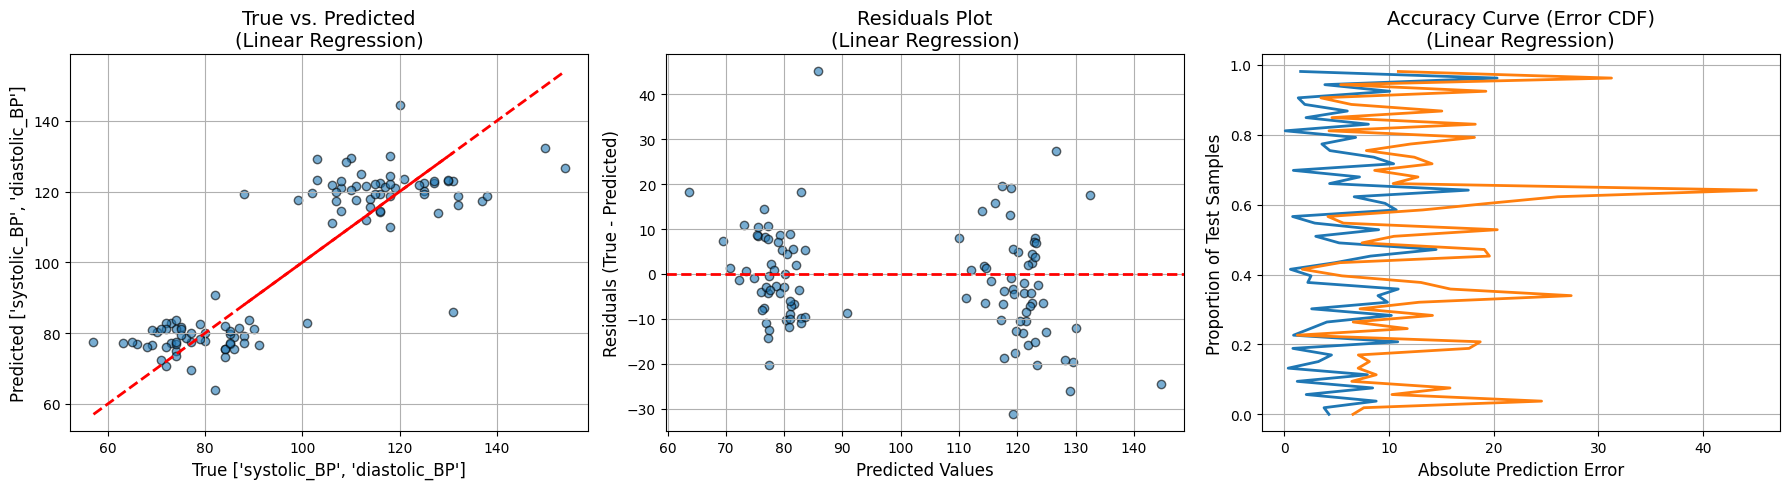

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Linear Regression'
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 3. Evaluate Performance and Store Results
metrics_lr = calculate_regression_metrics(y_test, y_pred_lr, tolerance=ACCURACY_TOLERANCE)
all_model_results[model_name] = metrics_lr
print(f"--- {model_name} Performance ---")
for metric, value in metrics_lr.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
plot_model_performance(y_test, y_pred_lr, model_name, SELECTED_TARGET)

--- Random Forest Performance ---
MAE: 9.0848
MSE: 147.2227
RMSE: 12.1335
R²: -0.1091
Accuracy (±10%): 62.2642


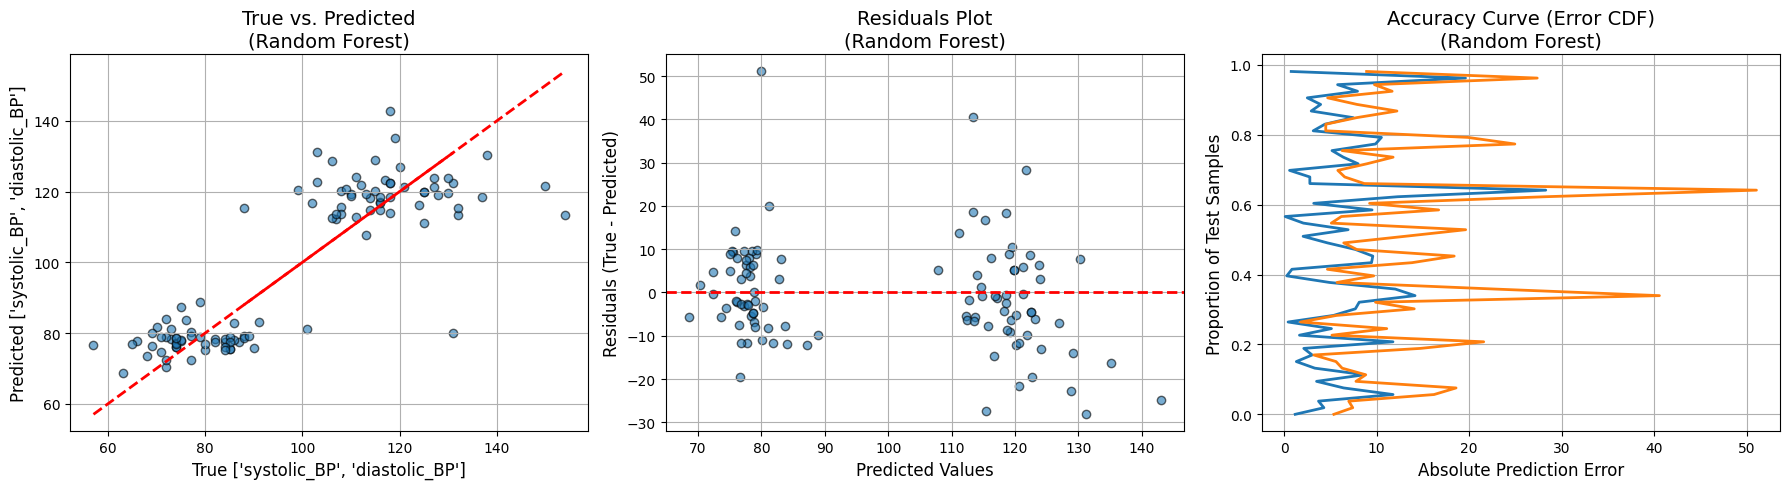

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Random Forest'
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Evaluate Performance and Store Results
metrics_rf = calculate_regression_metrics(y_test, y_pred_rf, tolerance=ACCURACY_TOLERANCE)
all_model_results[model_name] = metrics_rf
print(f"--- {model_name} Performance ---")
for metric, value in metrics_rf.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
plot_model_performance(y_test, y_pred_rf, model_name, SELECTED_TARGET)

--- Support Vector Regression Performance (Systolic BP) ---
MAE: 9.0689
MSE: 143.1890
RMSE: 11.9662
R²: 0.0068
Accuracy (±10%): 77.3585


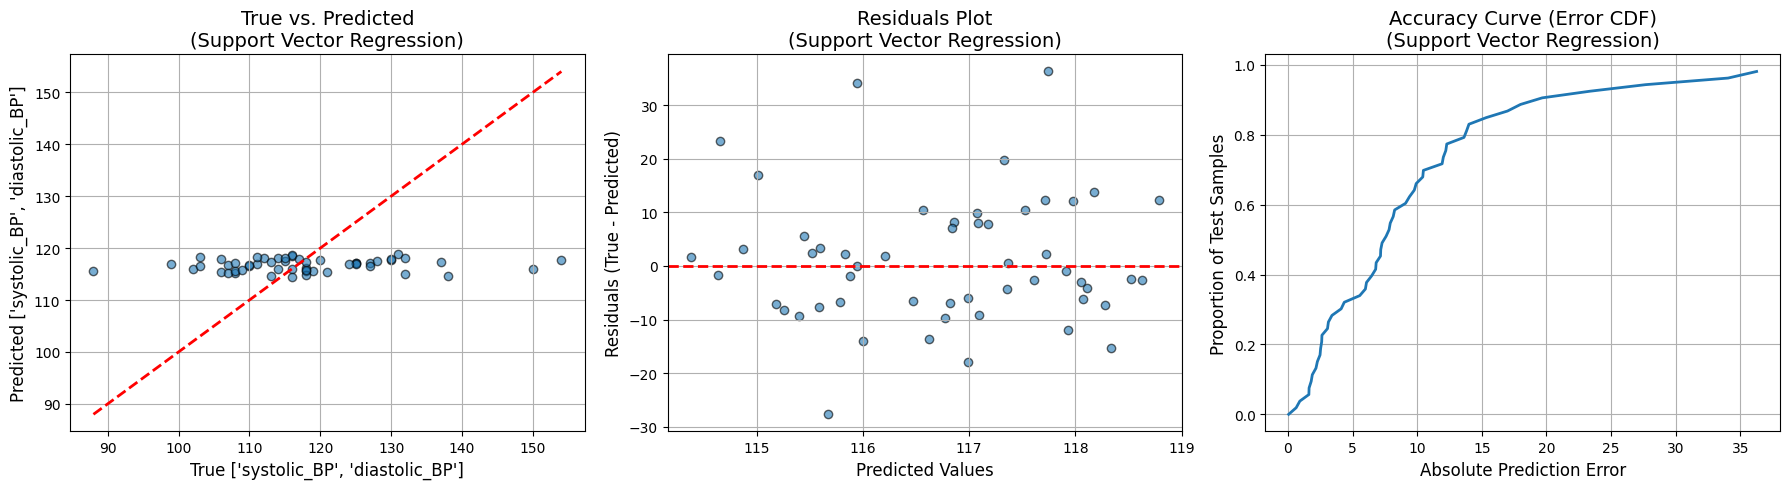

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Support Vector Regression'
svr_model = SVR()

# Select a single target variable for training in this cell (e.g., 'systolic_BP')
# You would need a separate cell for 'diastolic_BP'
y_train_systolic = y_train['systolic_BP']
y_test_systolic = y_test['systolic_BP']


svr_model.fit(X_train_scaled, y_train_systolic)

# 2. Make Predictions
y_pred_svr = svr_model.predict(X_test_scaled) # Corrected to use X_test_scaled

# 3. Evaluate Performance and Store Results
# Assuming you have a calculate_regression_metrics function defined
metrics_svr = calculate_regression_metrics(y_test_systolic, y_pred_svr, tolerance=ACCURACY_TOLERANCE)
# Store results in a dictionary if needed, similar to the previous approach
# all_model_results[model_name] = metrics_svr # This would need adjustment for target variable

print(f"--- {model_name} Performance (Systolic BP) ---")
for metric, value in metrics_svr.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
# Assuming you have a plot_model_performance function defined
plot_model_performance(y_test_systolic, y_pred_svr, model_name, SELECTED_TARGET)

--- Support Vector Regression Performance (Systolic BP) ---
MAE: 7.6591
MSE: 119.2645
RMSE: 10.9208
R²: -0.0098
Accuracy (±10%): 64.1509


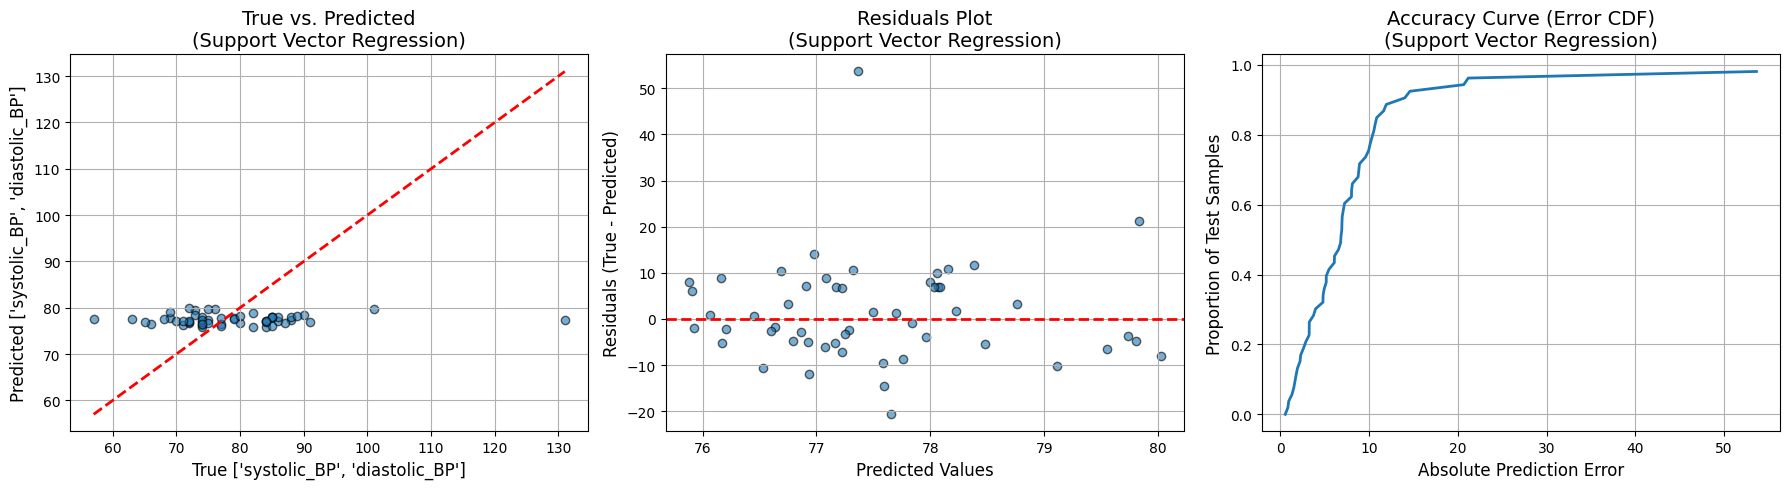

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Support Vector Regression'
svr_model = SVR()

# Select a single target variable for training in this cell (e.g., 'systolic_BP')
# You would need a separate cell for 'diastolic_BP'
y_train_systolic = y_train['diastolic_BP']
y_test_systolic = y_test['diastolic_BP']


svr_model.fit(X_train_scaled, y_train_systolic)

# 2. Make Predictions
y_pred_svr = svr_model.predict(X_test_scaled) # Corrected to use X_test_scaled

# 3. Evaluate Performance and Store Results
# Assuming you have a calculate_regression_metrics function defined
metrics_svr = calculate_regression_metrics(y_test_systolic, y_pred_svr, tolerance=ACCURACY_TOLERANCE)
# Store results in a dictionary if needed, similar to the previous approach
# all_model_results[model_name] = metrics_svr # This would need adjustment for target variable

print(f"--- {model_name} Performance (Systolic BP) ---")
for metric, value in metrics_svr.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
# Assuming you have a plot_model_performance function defined
plot_model_performance(y_test_systolic, y_pred_svr, model_name, SELECTED_TARGET)

--- XGBoost Performance ---
MAE: 9.6232
MSE: 170.7243
RMSE: 13.0662
R²: -0.2753
Accuracy (±10%): 56.6038


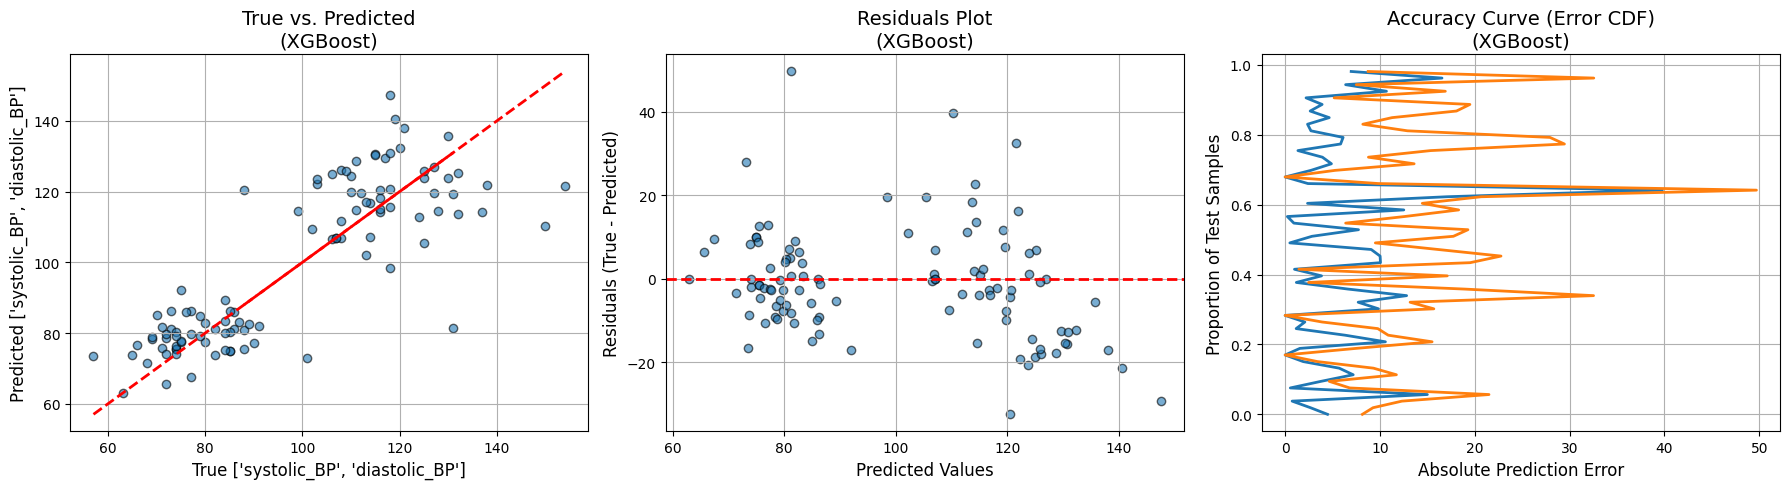

In [ ]:
# 1. Initialize and Train the Model
model_name = 'XGBoost'
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 3. Evaluate Performance and Store Results
metrics_xgb = calculate_regression_metrics(y_test, y_pred_xgb, tolerance=ACCURACY_TOLERANCE)
all_model_results[model_name] = metrics_xgb
print(f"--- {model_name} Performance ---")
for metric, value in metrics_xgb.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
plot_model_performance(y_test, y_pred_xgb, model_name, SELECTED_TARGET)

--- Neural Network Performance ---
MAE: 11.3246
MSE: 220.1790
RMSE: 14.8384
R²: -0.6563
Accuracy (±10%): 50.0000


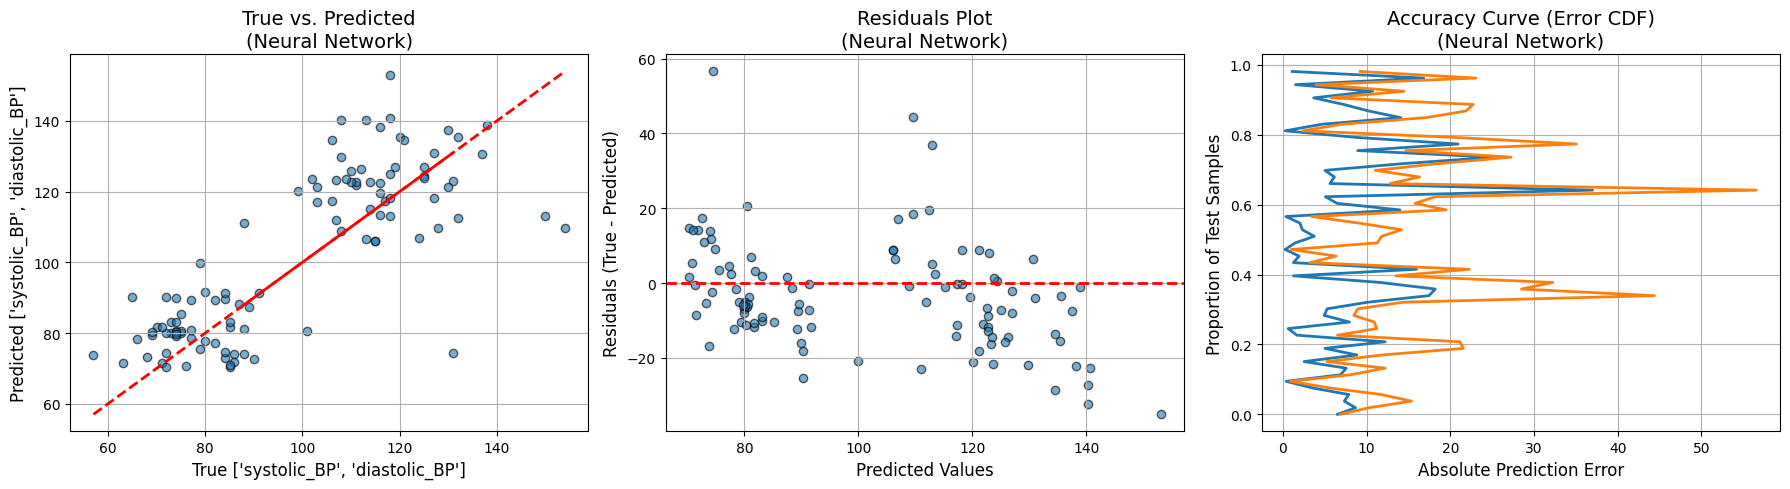

In [ ]:
# 1. Initialize and Train the Model
model_name = 'Neural Network'
nn_model = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=42)
nn_model.fit(X_train_scaled, y_train)

# 2. Make Predictions
y_pred_nn = nn_model.predict(X_test_scaled)

# 3. Evaluate Performance and Store Results
metrics_nn = calculate_regression_metrics(y_test, y_pred_nn, tolerance=ACCURACY_TOLERANCE)
all_model_results[model_name] = metrics_nn
print(f"--- {model_name} Performance ---")
for metric, value in metrics_nn.items():
    print(f"{metric}: {value:.4f}")

# 4. Plot Performance
plot_model_performance(y_test, y_pred_nn, model_name, SELECTED_TARGET)

# full data

--- Final Model Comparison for Target: '['systolic_BP', 'diastolic_BP']' ---


,MAE,MSE,RMSE,R²,Accuracy (±10%)
Linear Regression,8.767331,138.372548,11.763186,-0.053924,68.867925
Random Forest,7.992347,122.386194,11.062829,0.065139,66.981132
XGBoost,8.410351,139.837646,11.825297,-0.079295,66.037736
Neural Network,10.150697,193.756615,13.919649,-0.476444,60.377358


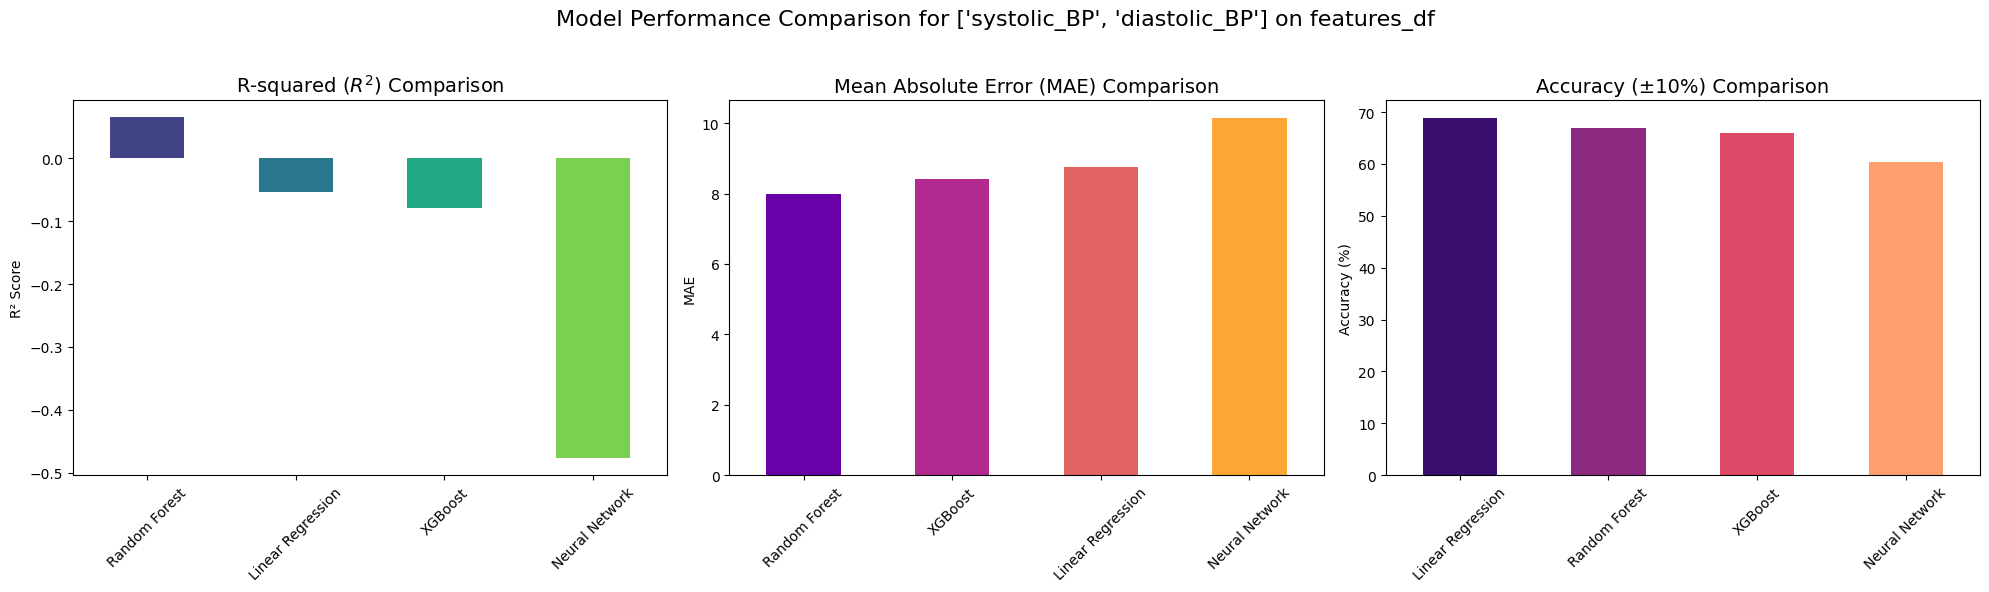

In [ ]:
# Convert the results dictionary to a pandas DataFrame for easy plotting
results_df = pd.DataFrame(all_model_results).T

print(f"--- Final Model Comparison for Target: '{SELECTED_TARGET}' ---")
display(results_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Model Performance Comparison for {SELECTED_TARGET} on {SELECTED_DF_NAME}', fontsize=16)

# Plot R-squared
results_df['R²'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color=sns.color_palette("viridis", len(results_df)))
axes[0].set_title('R-squared ($R^2$) Comparison', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE (lower is better)
results_df['MAE'].sort_values(ascending=True).plot(kind='bar', ax=axes[1], color=sns.color_palette("plasma", len(results_df)))
axes[1].set_title('Mean Absolute Error (MAE) Comparison', fontsize=14)
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot Custom Accuracy (higher is better)
acc_col_name = f'Accuracy (±{int(ACCURACY_TOLERANCE*100)}%)'
results_df[acc_col_name] = results_df.pop(list(results_df.columns)[-1]) # Ensure correct column name
results_df[acc_col_name].sort_values(ascending=False).plot(kind='bar', ax=axes[2], color=sns.color_palette("magma", len(results_df)))
axes[2].set_title(f'{acc_col_name} Comparison', fontsize=14)
axes[2].set_ylabel('Accuracy (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# PPG Only

--- Final Model Comparison for Target: '['systolic_BP', 'diastolic_BP']' ---


,MAE,MSE,RMSE,R²,Accuracy (±10%)
Linear Regression,9.214892,137.312576,11.718045,-0.036842,55.660377
Random Forest,8.949230,143.500441,11.979167,-0.082986,64.150943
XGBoost,9.390964,157.217407,12.538637,-0.189927,56.603774
Neural Network,9.946221,177.369515,13.318015,-0.342776,63.207547


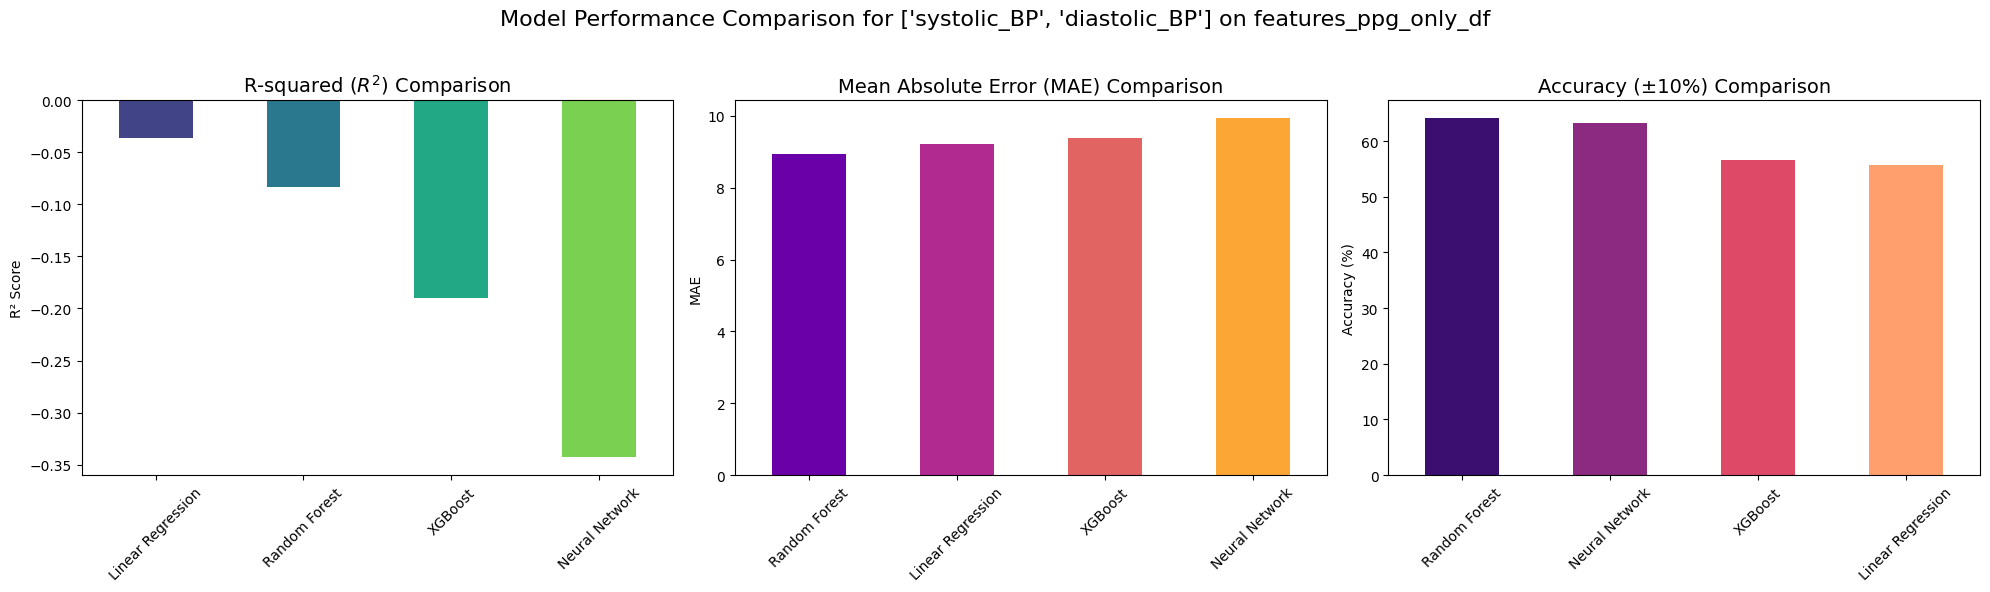

In [ ]:
# Convert the results dictionary to a pandas DataFrame for easy plotting
results_df = pd.DataFrame(all_model_results).T

print(f"--- Final Model Comparison for Target: '{SELECTED_TARGET}' ---")
display(results_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Model Performance Comparison for {SELECTED_TARGET} on {SELECTED_DF_NAME}', fontsize=16)

# Plot R-squared
results_df['R²'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color=sns.color_palette("viridis", len(results_df)))
axes[0].set_title('R-squared ($R^2$) Comparison', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE (lower is better)
results_df['MAE'].sort_values(ascending=True).plot(kind='bar', ax=axes[1], color=sns.color_palette("plasma", len(results_df)))
axes[1].set_title('Mean Absolute Error (MAE) Comparison', fontsize=14)
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot Custom Accuracy (higher is better)
acc_col_name = f'Accuracy (±{int(ACCURACY_TOLERANCE*100)}%)'
results_df[acc_col_name] = results_df.pop(list(results_df.columns)[-1]) # Ensure correct column name
results_df[acc_col_name].sort_values(ascending=False).plot(kind='bar', ax=axes[2], color=sns.color_palette("magma", len(results_df)))
axes[2].set_title(f'{acc_col_name} Comparison', fontsize=14)
axes[2].set_ylabel('Accuracy (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# No Vitals

--- Final Model Comparison for Target: '['systolic_BP', 'diastolic_BP']' ---


,MAE,MSE,RMSE,R²,Accuracy (±10%)
Linear Regression,8.829578,140.737287,11.863275,-0.070485,70.754717
Random Forest,7.952182,123.541900,11.114940,0.053979,66.037736
XGBoost,8.616166,143.720444,11.988346,-0.098982,64.150943
Neural Network,9.652450,161.922732,12.724886,-0.231767,55.660377


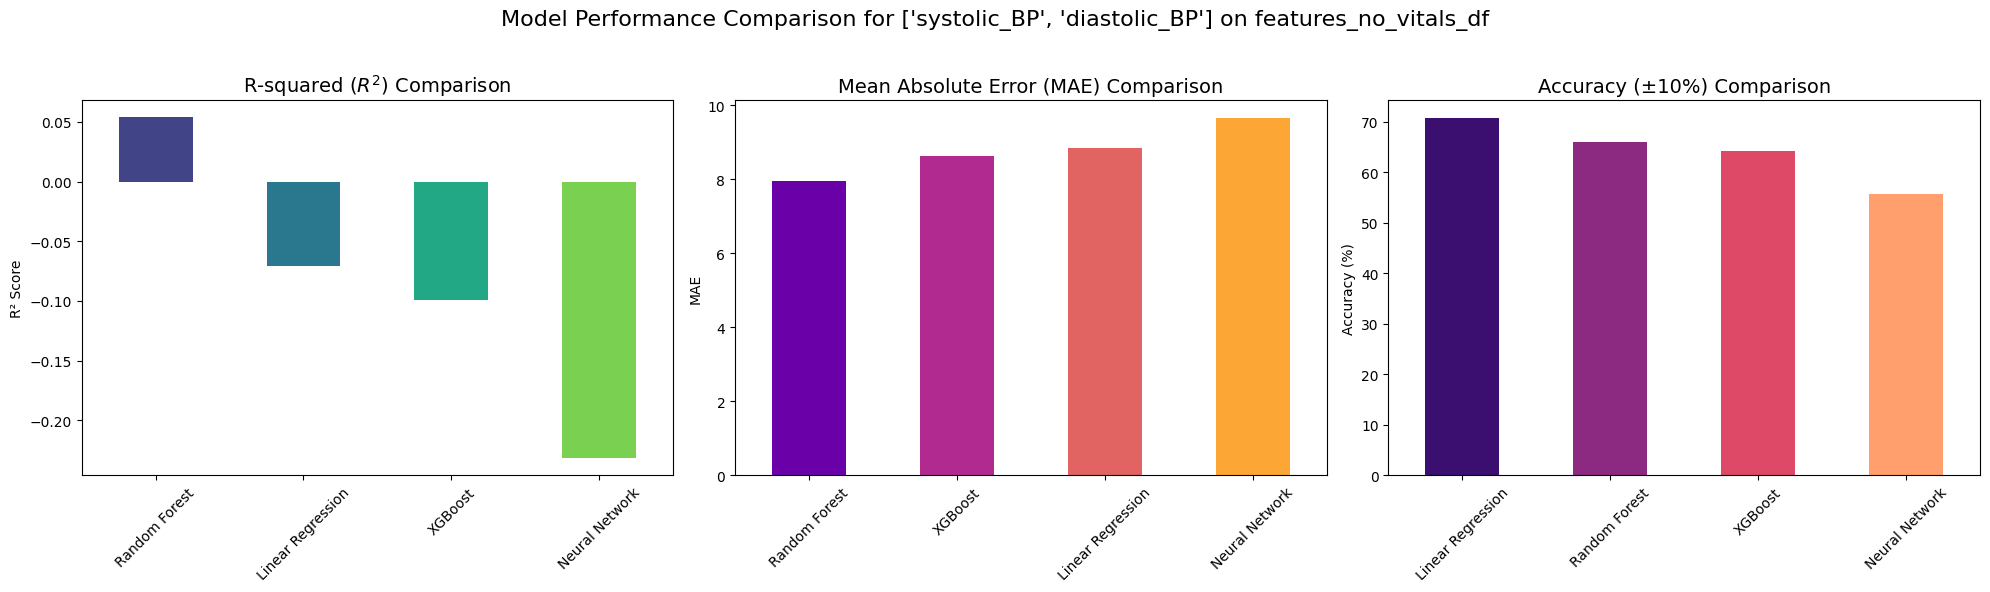

In [ ]:
# Convert the results dictionary to a pandas DataFrame for easy plotting
results_df = pd.DataFrame(all_model_results).T

print(f"--- Final Model Comparison for Target: '{SELECTED_TARGET}' ---")
display(results_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Model Performance Comparison for {SELECTED_TARGET} on {SELECTED_DF_NAME}', fontsize=16)

# Plot R-squared
results_df['R²'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color=sns.color_palette("viridis", len(results_df)))
axes[0].set_title('R-squared ($R^2$) Comparison', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE (lower is better)
results_df['MAE'].sort_values(ascending=True).plot(kind='bar', ax=axes[1], color=sns.color_palette("plasma", len(results_df)))
axes[1].set_title('Mean Absolute Error (MAE) Comparison', fontsize=14)
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot Custom Accuracy (higher is better)
acc_col_name = f'Accuracy (±{int(ACCURACY_TOLERANCE*100)}%)'
results_df[acc_col_name] = results_df.pop(list(results_df.columns)[-1]) # Ensure correct column name
results_df[acc_col_name].sort_values(ascending=False).plot(kind='bar', ax=axes[2], color=sns.color_palette("magma", len(results_df)))
axes[2].set_title(f'{acc_col_name} Comparison', fontsize=14)
axes[2].set_ylabel('Accuracy (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# No Demographic Data

--- Final Model Comparison for Target: '['systolic_BP', 'diastolic_BP']' ---


,MAE,MSE,RMSE,R²,Accuracy (±10%)
Linear Regression,9.194091,138.688715,11.776617,-0.048212,58.490566
Random Forest,9.084803,147.222668,12.133535,-0.109080,62.264151
XGBoost,9.623173,170.724335,13.066152,-0.275313,56.603774
Neural Network,11.324622,220.178951,14.838428,-0.656270,50.000000


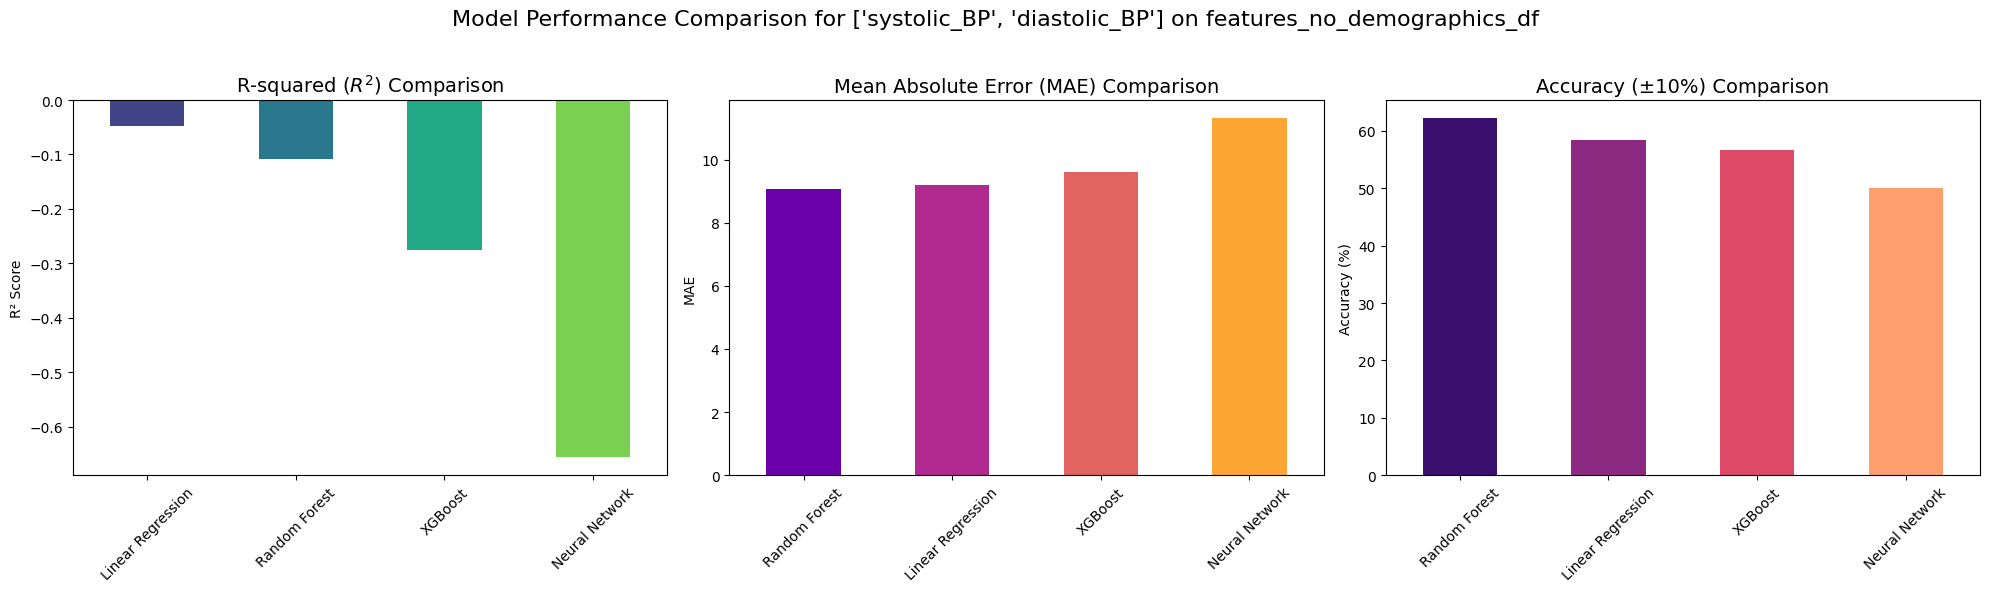

In [ ]:
# Convert the results dictionary to a pandas DataFrame for easy plotting
results_df = pd.DataFrame(all_model_results).T

print(f"--- Final Model Comparison for Target: '{SELECTED_TARGET}' ---")
display(results_df)

# Plotting the comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Model Performance Comparison for {SELECTED_TARGET} on {SELECTED_DF_NAME}', fontsize=16)

# Plot R-squared
results_df['R²'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color=sns.color_palette("viridis", len(results_df)))
axes[0].set_title('R-squared ($R^2$) Comparison', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE (lower is better)
results_df['MAE'].sort_values(ascending=True).plot(kind='bar', ax=axes[1], color=sns.color_palette("plasma", len(results_df)))
axes[1].set_title('Mean Absolute Error (MAE) Comparison', fontsize=14)
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot Custom Accuracy (higher is better)
acc_col_name = f'Accuracy (±{int(ACCURACY_TOLERANCE*100)}%)'
results_df[acc_col_name] = results_df.pop(list(results_df.columns)[-1]) # Ensure correct column name
results_df[acc_col_name].sort_values(ascending=False).plot(kind='bar', ax=axes[2], color=sns.color_palette("magma", len(results_df)))
axes[2].set_title(f'{acc_col_name} Comparison', fontsize=14)
axes[2].set_ylabel('Accuracy (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Nural Network try out

# CNN

In [ ]:
# ==============================================================================
# CELL 1: SETUP AND DATA LOADING
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Load your dataset ---
try:
    df = pd.read_csv('bp_dataset_resampled_200_V2.csv')
    print(f"✅ Successfully loaded 'bp_dataset_resampled_200_V2.csv' (Shape: {df.shape}).")
except FileNotFoundError as e:
    print(f"❌ Error: {e}. Please make sure the file is uploaded.")
    raise

# Handle categorical data: Convert 'userGender' to numbers
if 'userGender' in df.columns:
    df = pd.get_dummies(df, columns=['userGender'], drop_first=True)
    print("✅ Converted 'userGender' column to numeric format.")

✅ Successfully loaded 'bp_dataset_resampled_200_V2.csv' (Shape: (264, 409)).
✅ Converted 'userGender' column to numeric format.


In [ ]:
# ==============================================================================
# CELL 2: DATA PREPARATION
# ==============================================================================

# 1. Separate features (X) and targets (y)
# Targets are the two blood pressure columns
y = df[['systolic_BP', 'diastolic_BP']].values

# Features are the raw signal data
ir_cols = [f'ir_{i}' for i in range(200)]
red_cols = [f'red_{i}' for i in range(200)]

ir_signals = df[ir_cols].values
red_signals = df[red_cols].values

# 2. Reshape data into the CNN format (samples, timesteps, channels)
# We have two channels: one for IR signals, one for RED signals
X_signals = np.stack([ir_signals, red_signals], axis=-1)
print(f"Shape of signal data (X_signals): {X_signals.shape}")
print(f"Shape of target data (y): {y.shape}")

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_signals, y, test_size=0.2, random_state=42)

# 4. Scale the signal data
# It's important to scale each timestep and channel independently
# We reshape to 2D, fit the scaler, and then reshape back to 3D
scaler = StandardScaler()

# Reshape for scaling
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])

# Fit on training data and transform both sets
scaler.fit(X_train_reshaped)
X_train_scaled_reshaped = scaler.transform(X_train_reshaped)
X_test_scaled_reshaped = scaler.transform(X_test_reshaped)

# Reshape back to the original 3D format
X_train_scaled = X_train_scaled_reshaped.reshape(X_train.shape)
X_test_scaled = X_test_scaled_reshaped.reshape(X_test.shape)

print(f"\nData successfully prepared and scaled.")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")

Shape of signal data (X_signals): (264, 200, 2)
Shape of target data (y): (264, 2)

Data successfully prepared and scaled.
X_train shape: (211, 200, 2)
X_test shape: (53, 200, 2)


In [ ]:
# ==============================================================================
# CELL 3: BUILD THE 1D CNN MODEL
# ==============================================================================

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

model = Sequential([
    # First convolutional block
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Second convolutional block
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Flatten the features to feed into the dense layers
    Flatten(),

    # Dense layers for regression
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output layer: 2 neurons for systolic and diastolic BP
    # 'linear' activation is used for regression tasks
    Dense(2, activation='linear')
])

# Compile the model
model.compile(optimizer='adam',
              loss='mean_squared_error', # MSE is a standard loss for regression
              metrics=['mean_absolute_error']) # MAE is easier to interpret

# Print the model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 196, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 98, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 94, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       385,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,066 (1.51 MB)

 Trainable params: 396,066 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 9881.3516 - mean_absolute_error: 96.4101 - val_loss: 8339.9062 - val_mean_absolute_error: 88.3410
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 6499.8135 - mean_absolute_error: 75.1032 - val_loss: 3809.8848 - val_mean_absolute_error: 54.0708
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 3543.2898 - mean_absolute_error: 48.8029 - val_loss: 2393.7666 - val_mean_absolute_error: 39.9857
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3189.8865 - mean_absolute_error: 45.6010 - val_loss: 3099.9463 - val_mean_absolute_error: 49.1562
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2958.0974 - mean_absolute_error: 45.7684 - val_loss: 3252.4219 - val_mean_absolute_error: 50.3254
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2913.9670 - mean_absolute_error: 44.6839 - val_loss: 2757.3411 - val_mean_absolute_error: 44.3546
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2568.

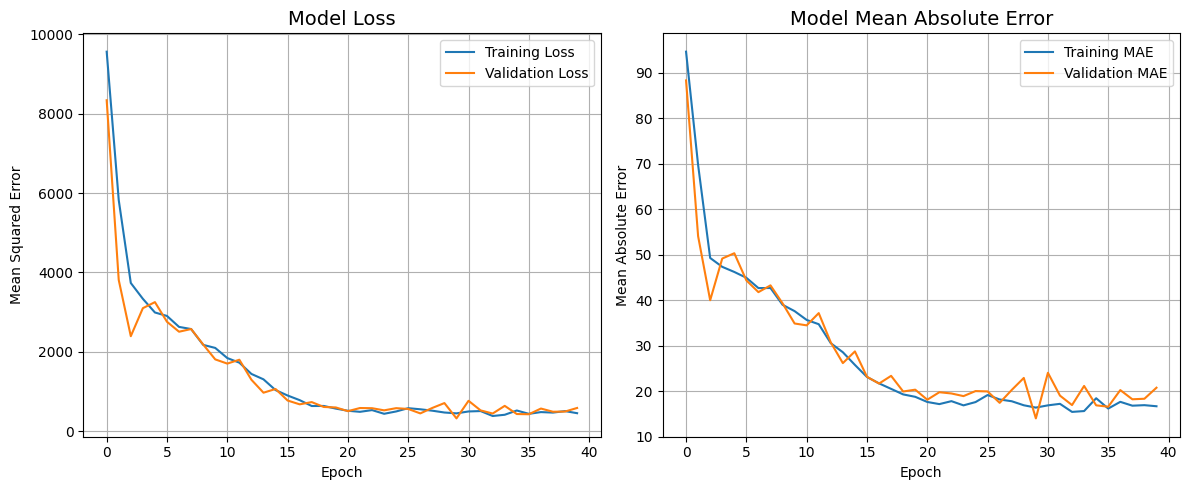


Final Test Set Mean Squared Error: 322.60
Final Test Set Mean Absolute Error: 14.00


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,97.410385,73,63.585403,18.589615,9.414597
1,114,99.646614,69,65.457314,14.353386,3.542686
2,120,109.217216,82,71.459625,10.782784,10.540375
3,119,97.983902,70,63.357830,21.016098,6.642170
4,132,105.248543,84,69.414978,26.751457,14.585022
5,108,111.042915,71,72.805069,-3.042915,-1.805069
6,131,113.166115,88,74.266953,17.833885,13.733047
7,130,110.426910,77,72.404175,19.573090,4.595825
8,116,102.711510,68,67.069305,13.288490,0.930695
9,127,103.856148,86,67.402603,23.143852,18.597397


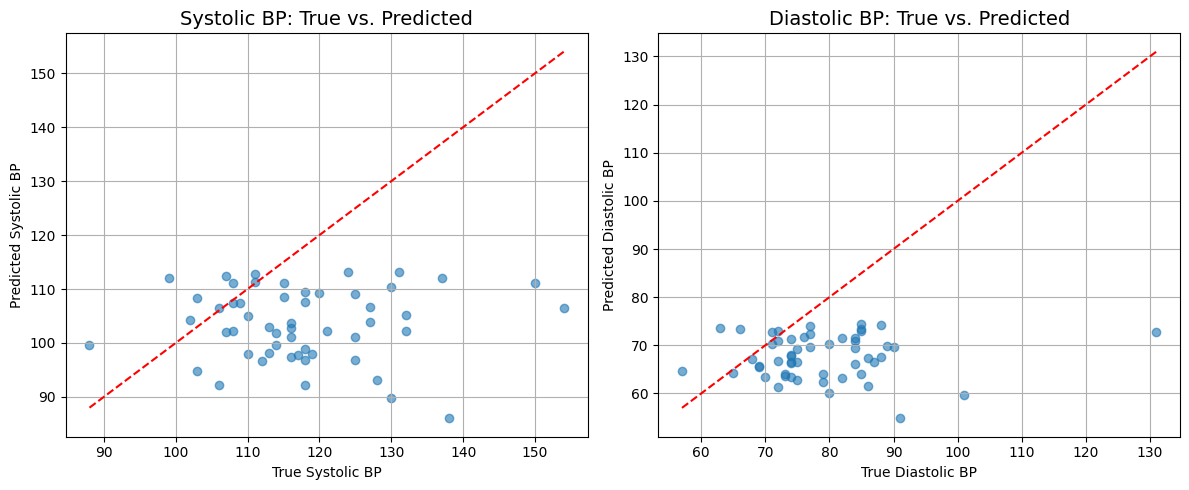

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

# Architecture 1: Standalone GRU Model

In [ ]:
# ==============================================================================
# Architecture 1: Standalone GRU Model
# ==============================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

model = Sequential([
    Input(shape=input_shape, name='signal_input'),

    # GRU layers can be stacked. 'return_sequences=True' is needed for all
    # but the last GRU layer to pass the full sequence to the next layer.
    GRU(units=64, return_sequences=True),
    Dropout(0.3),

    GRU(units=64, return_sequences=False), # Last GRU layer
    Dropout(0.3),

    # A dense layer to interpret the GRU's output
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Final output layer for regression
    Dense(2, activation='linear', name='output')
])

# Compile and summarize the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 200, 64)        │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,306 (165.26 KB)

 Trainable params: 42,306 (165.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step - loss: 10265.1367 - mean_absolute_error: 98.4286 - val_loss: 10131.1885 - val_mean_absolute_error: 98.0915
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - loss: 10405.7900 - mean_absolute_error: 99.2171 - val_loss: 10089.8809 - val_mean_absolute_error: 97.8845
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - loss: 10253.0254 - mean_absolute_error: 98.2320 - val_loss: 10011.6133 - val_mean_absolute_error: 97.4977
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - loss: 10219.7588 - mean_absolute_error: 97.9132 - val_loss: 9811.7275 - val_mean_absolute_error: 96.5024
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - loss: 9832.1113 - mean_absolute_error: 96.2749 - val_loss: 9296.9082 - val_mean_absolute_error: 93.8970
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 403ms/step - loss: 9262.1992 - mean_absolute_error: 93.4029 - val_loss: 8553.7480 - val_mean_absolute_error: 89.9246
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 406ms/step 

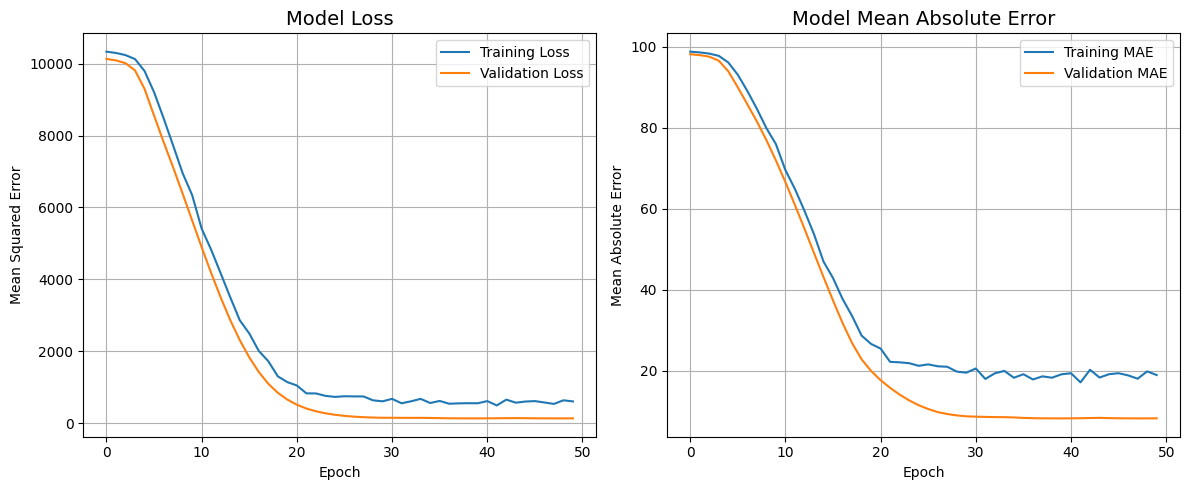


Final Test Set Mean Squared Error: 135.63
Final Test Set Mean Absolute Error: 8.26


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 449ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,116.067848,73,76.240540,-0.067848,-3.240540
1,114,116.068764,69,76.241272,-2.068764,-7.241272
2,120,116.068748,82,76.241226,3.931252,5.758774
3,119,116.068581,70,76.241096,2.931419,-6.241096
4,132,116.068848,84,76.241310,15.931152,7.758690
5,108,116.068863,71,76.241287,-8.068863,-5.241287
6,131,116.068878,88,76.241318,14.931122,11.758682
7,130,116.068855,77,76.241287,13.931145,0.758713
8,116,116.068832,68,76.241287,-0.068832,-8.241287
9,127,116.068367,86,76.240929,10.931633,9.759071


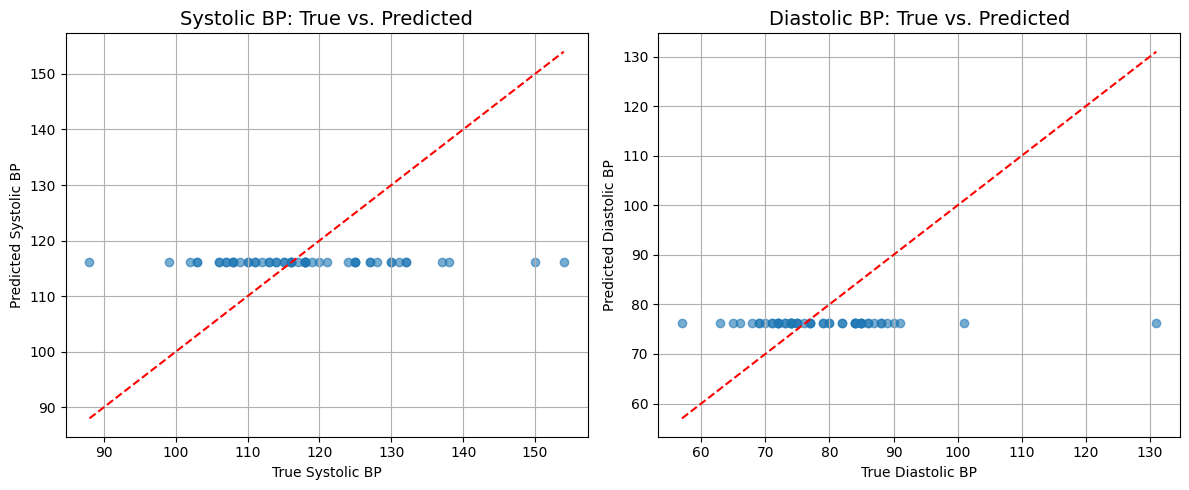

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

--- Custom Model Accuracy (within ±10% Tolerance) ---
🎯 Systolic BP Accuracy: 73.58%
🎯 Diastolic BP Accuracy: 60.38%
🏆 Overall Accuracy (Both Correct): 50.94%


# Architecture 2: Standalone LSTM Model

In [ ]:
# ==============================================================================
# Architecture 2: Standalone LSTM Model
# ==============================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

model = Sequential([
    Input(shape=input_shape, name='signal_input'),

    # Stacked LSTM layers
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),

    LSTM(units=64, return_sequences=False),
    Dropout(0.3),

    # Dense layers for regression
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Final output layer
    Dense(2, activation='linear', name='output')
])

# Compile and summarize the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 200, 64)        │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,466 (212.76 KB)

 Trainable params: 54,466 (212.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 390ms/step - loss: 10484.6016 - mean_absolute_error: 99.3684 - val_loss: 10106.3330 - val_mean_absolute_error: 97.9901
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - loss: 9970.6465 - mean_absolute_error: 97.1471 - val_loss: 9963.4424 - val_mean_absolute_error: 97.3298
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 10042.9844 - mean_absolute_error: 97.5215 - val_loss: 9672.1572 - val_mean_absolute_error: 95.9735
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - loss: 9803.7500 - mean_absolute_error: 96.2353 - val_loss: 9396.0615 - val_mean_absolute_error: 94.6408
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 9663.3545 - mean_absolute_error: 95.6228 - val_loss: 9092.1699 - val_mean_absolute_error: 93.1260
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 9028.0674 - mean_absolute_error: 92.4736 - val_loss: 8739.5752 - val_mean_absolute_error: 91.3230
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - lo

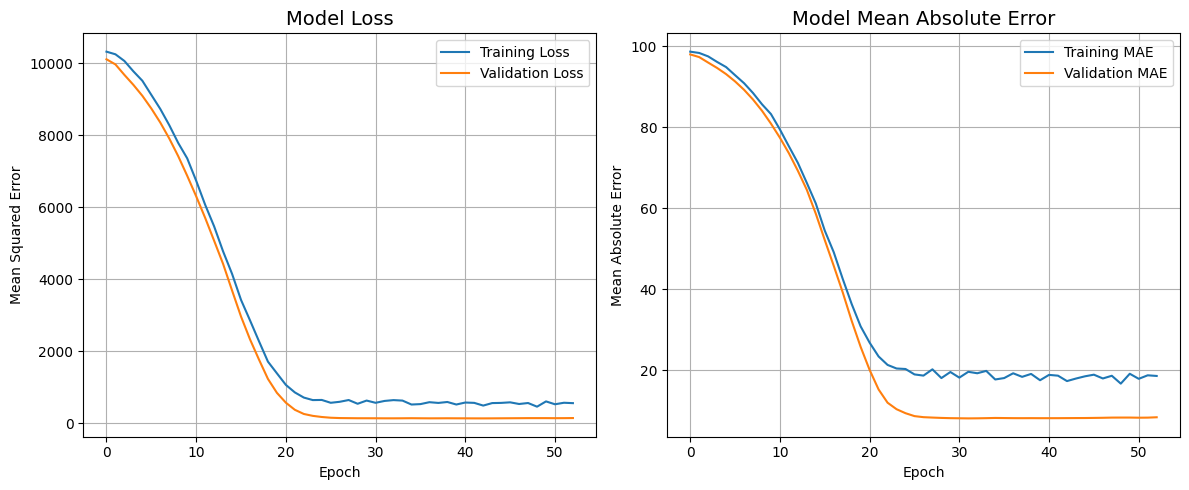


Final Test Set Mean Squared Error: 134.14
Final Test Set Mean Absolute Error: 8.20


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,115.822136,73,75.481964,0.177864,-2.481964
1,114,116.282845,69,76.687729,-2.282845,-7.687729
2,120,116.276970,82,76.684685,3.723030,5.315315
3,119,115.821465,70,75.481308,3.178535,-5.481308
4,132,116.279137,84,76.685837,15.720863,7.314163
5,108,116.277031,71,76.684616,-8.277031,-5.684616
6,131,116.278481,88,76.685387,14.721519,11.314613
7,130,116.276482,77,76.684311,13.723518,0.315689
8,116,116.278221,68,76.685089,-0.278221,-8.685089
9,127,115.822258,86,75.482071,11.177742,10.517929


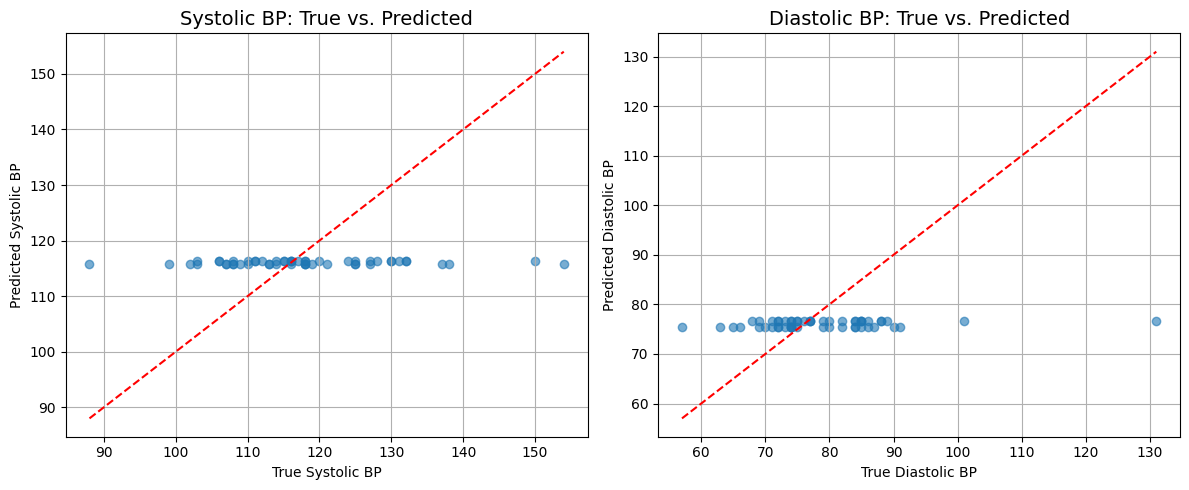

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

--- Custom Model Accuracy (within ±10% Tolerance) ---
🎯 Systolic BP Accuracy: 73.58%
🎯 Diastolic BP Accuracy: 64.15%
🏆 Overall Accuracy (Both Correct): 54.72%



# Architecture 3: Hybrid CNN-LSTM Model

In [ ]:
# ==============================================================================
# Architecture 3: Hybrid CNN-LSTM Model
# ==============================================================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Define the model using the Keras Functional API
signal_input = Input(shape=input_shape, name='signal_input')

# 1. Convolutional Block (to extract local features)
cnn = Conv1D(filters=32, kernel_size=5, activation='relu', padding='same')(signal_input)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.25)(cnn)

cnn = Conv1D(filters=64, kernel_size=5, activation='relu', padding='same')(cnn)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.25)(cnn)

# 2. LSTM Block (to learn temporal patterns from the extracted features)
lstm = LSTM(units=64, return_sequences=False)(cnn)
lstm = Dropout(0.5)(lstm)

# 3. Dense Block (for final prediction)
output = Dense(2, activation='linear', name='output')(lstm)

# Create and compile the final model
model = Model(inputs=signal_input, outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_input (InputLayer)       │ (None, 200, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 200, 32)        │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,810 (171.13 KB)

 Trainable params: 43,810 (171.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 10157.6016 - mean_absolute_error: 97.9867 - val_loss: 10013.5273 - val_mean_absolute_error: 97.5162
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 10132.3809 - mean_absolute_error: 97.7562 - val_loss: 9654.3447 - val_mean_absolute_error: 95.7593
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 9752.5439 - mean_absolute_error: 95.8247 - val_loss: 9343.7461 - val_mean_absolute_error: 94.2040
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 9594.2041 - mean_absolute_error: 95.0429 - val_loss: 9091.7432 - val_mean_absolute_error: 92.9034
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 9263.2656 - mean_absolute_error: 93.1251 - val_loss: 8866.4609 - val_mean_absolute_error: 91.7087
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - loss: 8898.7822 - mean_absolute_error: 91.6143 - val_loss: 8689.7402 - val_mean_absolute_error: 90.7388
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - loss: 

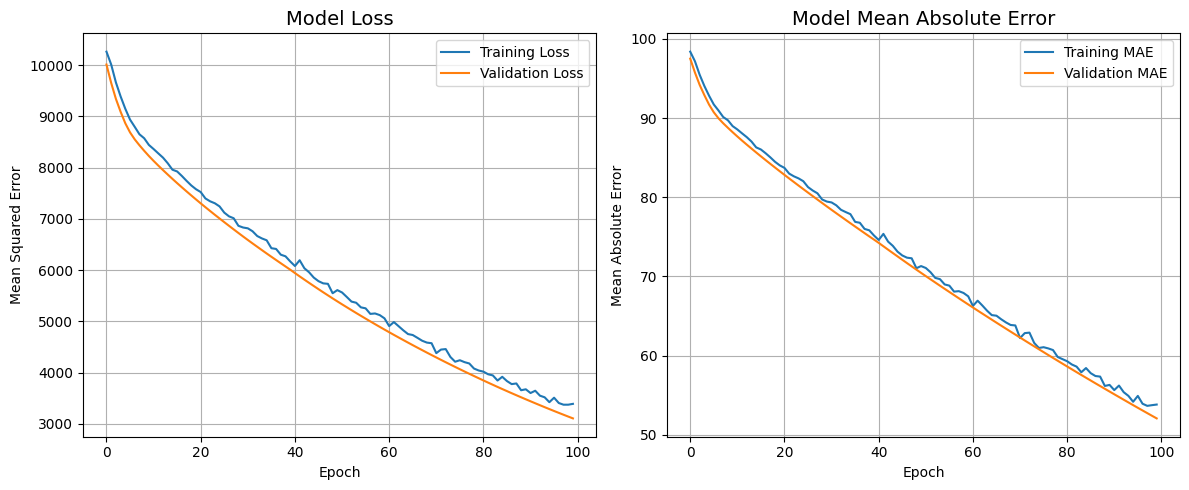


Final Test Set Mean Squared Error: 3108.00
Final Test Set Mean Absolute Error: 52.06


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,49.320190,73,43.005093,66.679810,29.994907
1,114,49.320183,69,43.005089,64.679817,25.994911
2,120,49.319069,82,43.004147,70.680931,38.995853
3,119,49.320190,70,43.005093,69.679810,26.994907
4,132,49.319199,84,43.004257,82.680801,40.995743
5,108,49.316391,71,43.001839,58.683609,27.998161
6,131,49.314754,88,43.000416,81.685246,44.999584
7,130,49.318249,77,43.003441,80.681751,33.996559
8,116,49.320122,68,43.005032,66.679878,24.994968
9,127,49.320190,86,43.005093,77.679810,42.994907


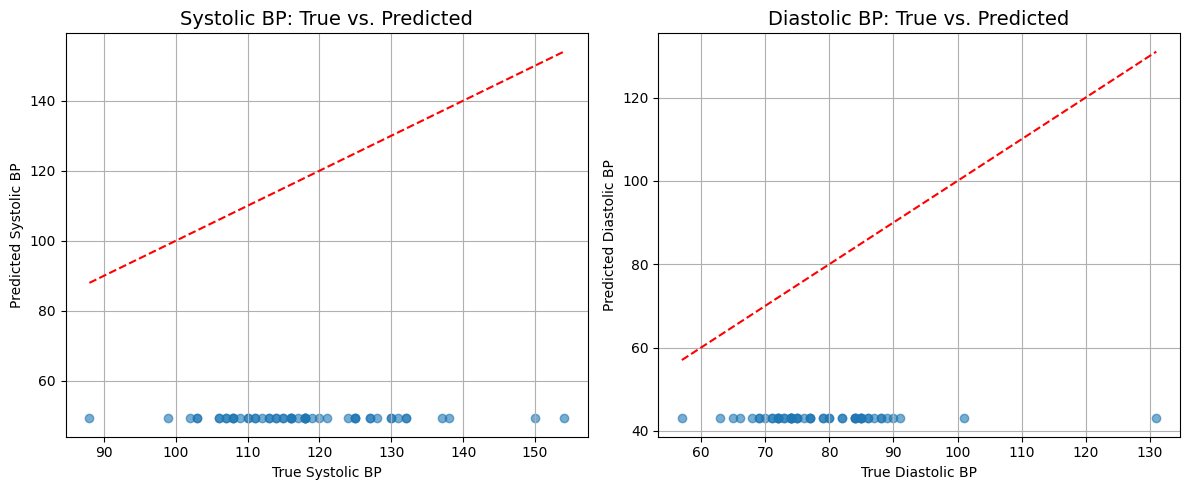

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

--- Custom Model Accuracy (within ±10% Tolerance) ---
🎯 Systolic BP Accuracy: 0.00%
🎯 Diastolic BP Accuracy: 0.00%
🏆 Overall Accuracy (Both Correct): 0.00%


# Architecture 4: Transformer Model (Experimental)

In [ ]:
# ==============================================================================
# Architecture 4: Transformer Model (Experimental)
# ==============================================================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Define the Transformer Encoder block as a function
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs) # Add & Norm

    # Feed Forward Part
    ff_x = Dense(ff_dim, activation="relu")(x)
    ff_x = Dropout(dropout)(ff_x)
    ff_x = Dense(inputs.shape[-1])(ff_x)
    # Add & Norm
    return LayerNormalization(epsilon=1e-6)(x + ff_x)


# --- Build the Model ---
inputs = Input(shape=input_shape)
x = inputs

# Create multiple Transformer blocks
for _ in range(2): # Stacking 2 transformer blocks
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=64, dropout=0.25)

# After the Transformer blocks, we need to pool the output
# before feeding it to the final regressor head.
x = GlobalAveragePooling1D(data_format="channels_last")(x)

# Final prediction layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(2, activation="linear")(x)

# Create and compile the model
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 200, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 2)    │      2,818 │ input_layer_7[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_49          │ (None, 200, 2)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 200, 2)    │          0 │ dropout_49[0][0], │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 2)    │          4 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 200, 64)   │        192 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 200, 64)   │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 200, 2)    │        130 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 200, 2)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 2)    │          4 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 2)    │      2,818 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 200, 2)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 200, 2)    │          0 │ dropout_52[0][0], │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 2)    │          4 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 200, 64)   │        192 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 200, 64)   │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 200, 2)    │        130 │ dropout_53[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 200, 2)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_27[0][0]  

 Total params: 6,618 (25.85 KB)

 Trainable params: 6,618 (25.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - loss: 10282.4062 - mean_absolute_error: 98.5709 - val_loss: 10121.9199 - val_mean_absolute_error: 98.0526
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 956ms/step - loss: 10220.3623 - mean_absolute_error: 98.2414 - val_loss: 10099.9336 - val_mean_absolute_error: 97.9451
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 579ms/step - loss: 10465.9238 - mean_absolute_error: 99.3185 - val_loss: 10077.2080 - val_mean_absolute_error: 97.8339
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 841ms/step - loss: 10285.5166 - mean_absolute_error: 98.5999 - val_loss: 10053.3633 - val_mean_absolute_error: 97.7172
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 546ms/step - loss: 10276.7236 - mean_absolute_error: 98.4424 - val_loss: 10028.2207 - val_mean_absolute_error: 97.5937
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - loss: 10246.3984 - mean_absolute_error: 98.2599 - val_loss: 10001.6133 - val_mean_absolute_error: 97.4627
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 653ms/step 

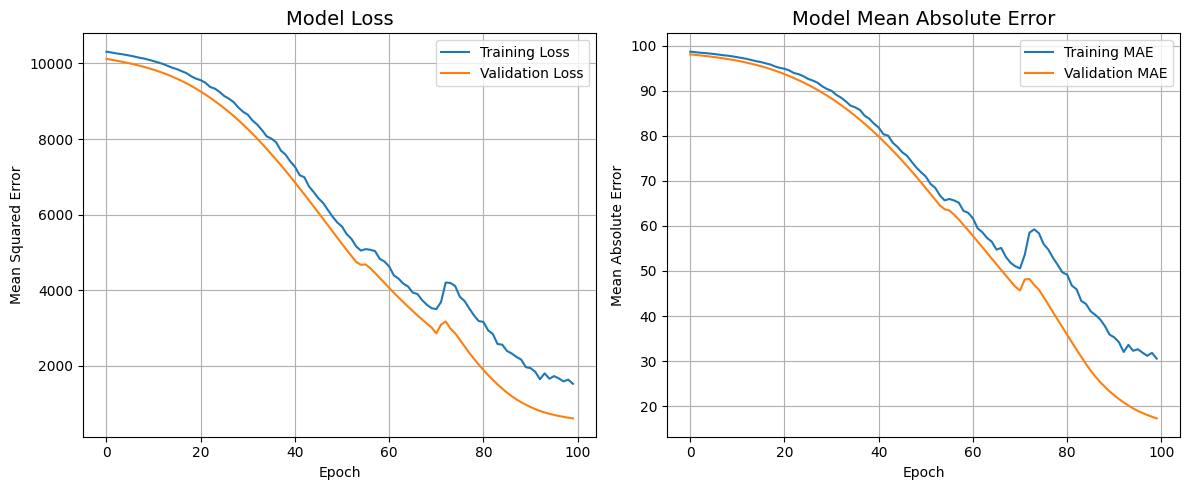


Final Test Set Mean Squared Error: 604.21
Final Test Set Mean Absolute Error: 17.29


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 376ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,105.825180,73,87.568977,10.174820,-14.568977
1,114,105.825180,69,87.568977,8.174820,-18.568977
2,120,41.849300,82,34.595692,78.150700,47.404308
3,119,103.628242,70,85.436798,15.371758,-15.436798
4,132,105.825180,84,87.568977,26.174820,-3.568977
5,108,105.825180,71,87.568977,2.174820,-16.568977
6,131,105.825180,88,87.568977,25.174820,0.431023
7,130,105.825180,77,87.568977,24.174820,-10.568977
8,116,105.825180,68,87.568977,10.174820,-19.568977
9,127,37.419678,86,30.882084,89.580322,55.117916


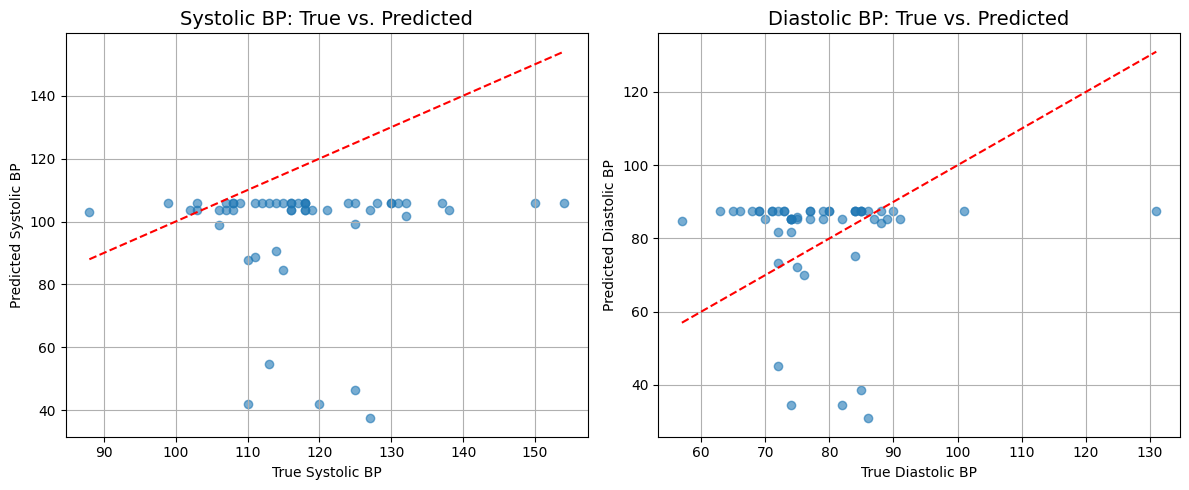

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

--- Custom Model Accuracy (within ±10% Tolerance) ---
🎯 Systolic BP Accuracy: 37.74%
🎯 Diastolic BP Accuracy: 37.74%
🏆 Overall Accuracy (Both Correct): 3.77%


# Architecture 5: Simple RNN Model (Educational Baseline)

In [ ]:
# ==============================================================================
# Architecture 5: Simple RNN Model (Educational Baseline)
# ==============================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input

# Get the input shape from our training data
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

model = Sequential([
    Input(shape=input_shape, name='signal_input'),

    # A SimpleRNN layer. Prone to vanishing gradients on long sequences.
    SimpleRNN(units=64, return_sequences=False),
    Dropout(0.3),

    # Dense layers for regression
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Final output layer
    Dense(2, activation='linear', name='output')
])

# Compile and summarize the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,578 (33.51 KB)

 Trainable params: 8,578 (33.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==============================================================================
# CELL 4: TRAIN THE NEURAL NETWORK
# ==============================================================================

# Define an early stopping callback to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100, # Set a high number of epochs; early stopping will find the best one
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    verbose=1 # Set to 1 to see progress
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 10102.3018 - mean_absolute_error: 97.5894 - val_loss: 10007.8330 - val_mean_absolute_error: 97.4984
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 10116.4941 - mean_absolute_error: 97.7374 - val_loss: 9794.0732 - val_mean_absolute_error: 96.4856
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 9798.5215 - mean_absolute_error: 96.3288 - val_loss: 9538.7646 - val_mean_absolute_error: 95.2322
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 9850.9277 - mean_absolute_error: 96.4165 - val_loss: 9277.2393 - val_mean_absolute_error: 93.9157
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9317.4404 - mean_absolute_error: 93.8640 - val_loss: 8986.6582 - val_mean_absolute_error: 92.4209
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 9277.5742 - mean_absolute_error: 93.3421 - val_loss: 8671.4834 - val_mean_absolute_error: 90.7542
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 87

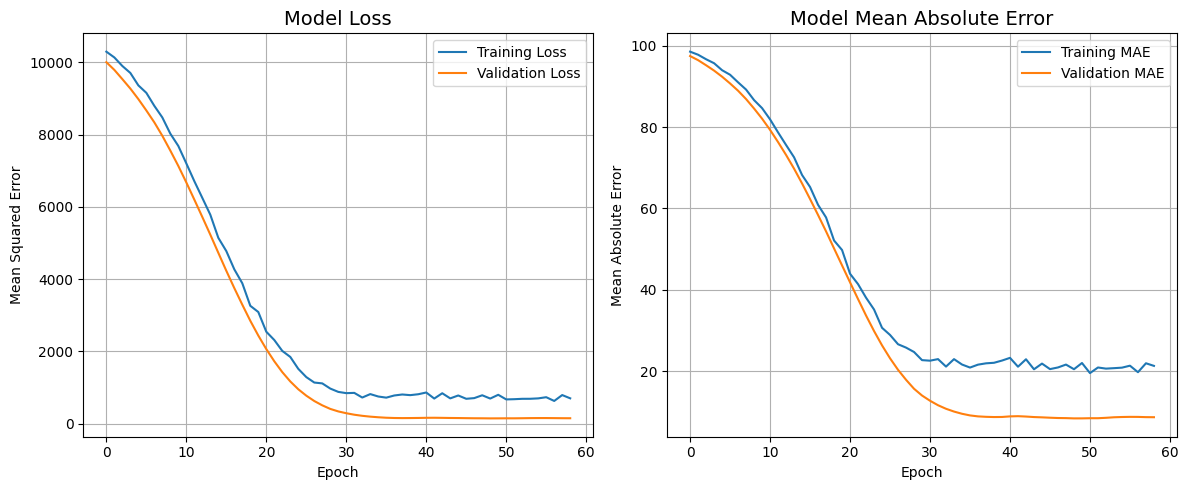


Final Test Set Mean Squared Error: 147.09
Final Test Set Mean Absolute Error: 8.37


In [ ]:
# ==============================================================================
# CELL 5: EVALUATE MODEL PERFORMANCE
# ==============================================================================

# Plot training & validation loss values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss', fontsize=14)
plt.ylabel('Mean Squared Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title('Model Mean Absolute Error', fontsize=14)
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluate the final model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Test Set Mean Squared Error: {test_loss:.2f}")
print(f"Final Test Set Mean Absolute Error: {test_mae:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
--- True vs. Predicted Values (1D CNN) ---


,True Systolic,Predicted Systolic,True Diastolic,Predicted Diastolic,Systolic Error,Diastolic Error
0,116,111.897346,73,74.260010,4.102654,-1.260010
1,114,115.735420,69,76.139503,-1.735420,-7.139503
2,120,111.869423,82,74.242226,8.130577,7.757774
3,119,111.885574,70,74.252800,7.114426,-4.252800
4,132,115.720482,84,76.129555,16.279518,7.870445
5,108,115.708687,71,76.121742,-7.708687,-5.121742
6,131,115.715523,88,76.126282,15.284477,11.873718
7,130,115.706062,77,76.120003,14.293938,0.879997
8,116,115.714104,68,76.125252,0.285896,-8.125252
9,127,111.895332,86,74.259071,15.104668,11.740929


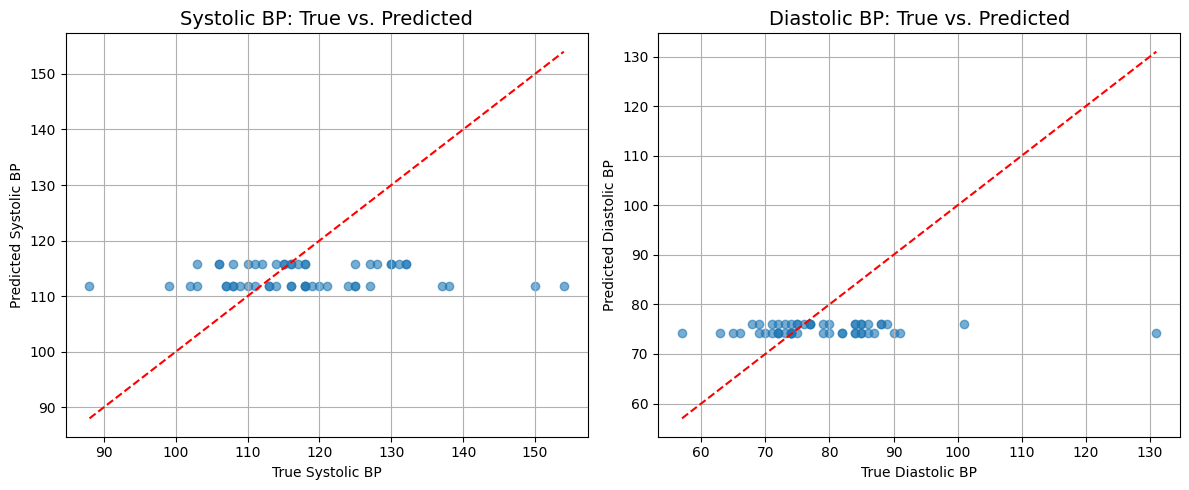

In [ ]:
# ==============================================================================
# CELL 6: ANALYZE PREDICTIONS
# ==============================================================================

# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'True Systolic': y_test[:, 0],
    'Predicted Systolic': y_pred[:, 0],
    'True Diastolic': y_test[:, 1],
    'Predicted Diastolic': y_pred[:, 1]
})
comparison_df['Systolic Error'] = comparison_df['True Systolic'] - comparison_df['Predicted Systolic']
comparison_df['Diastolic Error'] = comparison_df['True Diastolic'] - comparison_df['Predicted Diastolic']

print("--- True vs. Predicted Values (1D CNN) ---")
display(comparison_df.head(10))

# Plot True vs. Predicted values
plt.figure(figsize=(12, 5))

# Systolic BP plot
plt.subplot(1, 2, 1)
plt.scatter(comparison_df['True Systolic'], comparison_df['Predicted Systolic'], alpha=0.6)
plt.plot([min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], [min(comparison_df['True Systolic']), max(comparison_df['True Systolic'])], 'r--')
plt.title('Systolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Systolic BP')
plt.ylabel('Predicted Systolic BP')
plt.grid(True)

# Diastolic BP plot
plt.subplot(1, 2, 2)
plt.scatter(comparison_df['True Diastolic'], comparison_df['Predicted Diastolic'], alpha=0.6)
plt.plot([min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], [min(comparison_df['True Diastolic']), max(comparison_df['True Diastolic'])], 'r--')
plt.title('Diastolic BP: True vs. Predicted', fontsize=14)
plt.xlabel('True Diastolic BP')
plt.ylabel('Predicted Diastolic BP')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# CELL 7: CUSTOM ACCURACY EVALUATION
# ==============================================================================

def calculate_bp_accuracy(y_true, y_pred, tolerance=0.1):
    """
    Calculates the percentage of predictions within a given tolerance
    for systolic, diastolic, and overall blood pressure.

    Args:
    y_true (np.array): Ground truth values, shape (n_samples, 2)
    y_pred (np.array): Predicted values, shape (n_samples, 2)
    tolerance (float): The percentage tolerance (e.g., 0.1 for ±10%)

    Returns:
    A tuple containing systolic, diastolic, and overall accuracy percentages.
    """
    # Calculate absolute percentage error for each prediction
    # Adding a small epsilon to the denominator to avoid division by zero
    absolute_percentage_error = np.abs((y_true - y_pred) / (y_true + 1e-6))

    # Check if systolic predictions are within tolerance
    systolic_accurate = absolute_percentage_error[:, 0] <= tolerance
    systolic_accuracy_percent = np.mean(systolic_accurate) * 100

    # Check if diastolic predictions are within tolerance
    diastolic_accurate = absolute_percentage_error[:, 1] <= tolerance
    diastolic_accuracy_percent = np.mean(diastolic_accurate) * 100

    # For overall accuracy, BOTH systolic and diastolic must be within tolerance
    # for a given sample. We use a logical 'and' operation.
    overall_accurate = np.logical_and(systolic_accurate, diastolic_accurate)
    overall_accuracy_percent = np.mean(overall_accurate) * 100

    return systolic_accuracy_percent, diastolic_accuracy_percent, overall_accuracy_percent

# --- Calculate and Display the Custom Accuracy ---

# Define the tolerance for your accuracy calculation.
# For example, 0.1 means a prediction is "accurate" if it's within ±10% of the true value.
ACCURACY_TOLERANCE = 0.1

# The y_test and y_pred variables should already exist from running the previous cell
sys_acc, dia_acc, overall_acc = calculate_bp_accuracy(y_test, y_pred, tolerance=ACCURACY_TOLERANCE)

print(f"--- Custom Model Accuracy (within ±{int(ACCURACY_TOLERANCE*100)}% Tolerance) ---")
print(f"🎯 Systolic BP Accuracy: {sys_acc:.2f}%")
print(f"🎯 Diastolic BP Accuracy: {dia_acc:.2f}%")
print(f"🏆 Overall Accuracy (Both Correct): {overall_acc:.2f}%")

--- Custom Model Accuracy (within ±10% Tolerance) ---
🎯 Systolic BP Accuracy: 71.70%
🎯 Diastolic BP Accuracy: 58.49%
🏆 Overall Accuracy (Both Correct): 49.06%


# Conjoining Feture-extracted data and Raw PPG data

In [ ]:
# ==============================================================================
# CELL 1: LOADING AND MERGING DATASETS
# ==============================================================================
import pandas as pd
import numpy as np

# --- Load both datasets ---
try:
    # This dataset contains the raw signals and demographic/target data
    raw_data_df = pd.read_csv('bp_dataset_resampled_200_V2.csv')
    # This dataset contains the pre-extracted statistical features
    features_df = pd.read_csv('features.csv')
    print("✅ Successfully loaded both datasets.")
    print(f"Raw data shape: {raw_data_df.shape}")
    print(f"Features data shape: {features_df.shape}")
except FileNotFoundError as e:
    print(f"❌ Error: {e}. Please make sure both CSV files are uploaded.")
    raise

# --- Combine the datasets ---
# Identify the columns that are unique to the features_df
# These are the statistical features we want to add to our main dataframe.
raw_data_cols = raw_data_df.columns
feature_cols = features_df.columns
unique_feature_cols = [col for col in feature_cols if col not in raw_data_cols]

print(f"\nFound {len(unique_feature_cols)} unique statistical features to add.")

# Concatenate the unique columns from features_df to raw_data_df
# This works because we assume the rows are in the same order.
combined_df = pd.concat([raw_data_df, features_df[unique_feature_cols]], axis=1)

print(f"✅ Successfully combined datasets.")
print(f"New combined DataFrame shape: {combined_df.shape}")

# Display the first few rows with some of the new columns to verify
print("\n--- Verifying Combined Data ---")
cols_to_show = ['systolic_BP', 'ir_0', 'red_0'] + unique_feature_cols[:3] # Show first 3 new features
display(combined_df[cols_to_show].head())

# --- Final Pre-processing on the Combined DataFrame ---
# Handle categorical data: Convert 'userGender' to numbers
if 'userGender' in combined_df.columns:
    combined_df = pd.get_dummies(combined_df, columns=['userGender'], drop_first=True)
    print("\n✅ Converted 'userGender' column to numeric format.")

In [ ]:
# ==============================================================================
# CELL 2: DATA PREPARATION FOR HYBRID MODEL
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. Separate features and targets ---
y = combined_df[['systolic_BP', 'diastolic_BP']].values

# --- 2. Prepare the two sets of input features ---

# Input 1: The raw signal data
ir_cols = [f'ir_{i}' for i in range(200)]
red_cols = [f'red_{i}' for i in range(200)]
X_signals = np.stack([combined_df[ir_cols].values, combined_df[red_cols].values], axis=-1)

# Input 2: All other features (demographics, vitals, statistical features)
signal_cols = ir_cols + red_cols
target_cols = ['systolic_BP', 'diastolic_BP']
non_signal_cols = [col for col in combined_df.columns if col not in signal_cols and col not in target_cols]
X_features = combined_df[non_signal_cols].values

print(f"Signal data shape (Input 1): {X_signals.shape}")
print(f"Tabular features shape (Input 2): {X_features.shape}")

# --- 3. Split all data into training and testing sets ---
X_train_sig, X_test_sig, X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_signals, X_features, y, test_size=0.2, random_state=42
)

# --- 4. Scale both sets of features ---
signal_scaler = StandardScaler()
feature_scaler = StandardScaler()

# Scale Signals
X_train_sig_scaled = signal_scaler.fit_transform(X_train_sig.reshape(-1, X_train_sig.shape[-1])).reshape(X_train_sig.shape)
X_test_sig_scaled = signal_scaler.transform(X_test_sig.reshape(-1, X_test_sig.shape[-1])).reshape(X_test_sig.shape)

# Scale Tabular Features
X_train_feat_scaled = feature_scaler.fit_transform(X_train_feat)
X_test_feat_scaled = feature_scaler.transform(X_test_feat)

print("\n✅ Data successfully prepared for the two-input hybrid model.")

In [ ]:
# ==============================================================================
# CELL 3: BUILD AND TRAIN THE ENHANCED HYBRID MODEL
# ==============================================================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GRU, Dense, Dropout, concatenate
from tensorflow.keras.callbacks import EarlyStopping

# --- Define the two input branches ---
# Branch 1: For raw signals (processed by CNN and GRU)
signal_input = Input(shape=(X_train_sig_scaled.shape[1], X_train_sig_scaled.shape[2]), name='signal_input')
cnn = Conv1D(filters=32, kernel_size=5, activation='relu')(signal_input)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.25)(cnn)
gru = GRU(units=64)(cnn)
gru = Dropout(0.5)(gru)

# Branch 2: For all other features (processed by a Dense layer)
feature_input = Input(shape=(X_train_feat_scaled.shape[1],), name='feature_input')
dense_feat = Dense(32, activation='relu')(feature_input)

# --- Merge the two branches ---
combined = concatenate([gru, dense_feat])

# --- Final prediction layers ---
final_dense = Dense(128, activation='relu')(combined)
final_dense = Dropout(0.5)(final_dense)
output = Dense(2, activation='linear', name='output')(final_dense)

# --- Create, compile, and train the model ---
model = Model(inputs=[signal_input, feature_input], outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])
model.summary()

# Define callbacks and train
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    [X_train_sig_scaled, X_train_feat_scaled], # Provide both inputs as a list
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=([X_test_sig_scaled, X_test_feat_scaled], y_test),
    callbacks=[early_stopping],
    verbose=1
)

In [ ]:
# --- STEP 1: Load dataset ---

df = pd.read_csv("/content/drive/MyDrive/Defence/BP_Measuring_finalDataV2.csv")
display(df.head())

,_id,serialNumber,ir[0],ir[1],ir[2],ir[3],ir[4],ir[5],ir[6],ir[7],...,red[169],spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP
0,689666a4054bb9ca6f371a48,1,53465,53297,53166,53039,53234.0,53247.0,53156.0,53171.0,...,NaN,100,107,44,Male,180.0,98,30.246914,122,83
1,689666a4054bb9ca6f371a49,2,54755,54760,54767,54775,54782.0,54785.0,54804.0,54817.0,...,30759.0,100,125,30,Female,154.0,43,18.131219,102,68
2,689666a4054bb9ca6f371a4a,3,61920,61724,61878,61801,61611.0,61651.0,61801.0,61822.0,...,NaN,100,93,61,Female,144.0,62,29.899691,141,93
3,689666a4054bb9ca6f371a4b,4,59870,59829,59868,59922,59982.0,59954.0,59904.0,59956.0,...,NaN,98,71,45,Male,172.0,103,34.816117,139,96
4,689666a4054bb9ca6f371a4c,5,61487,61599,61710,61695,61531.0,61550.0,61506.0,61582.0,...,45313.0,98,166,23,Male,172.0,88,29.745809,112,75


In [ ]:
df2 = pd.read_csv("/content/bp_dataset_resampled_200_V2.csv")
display(df2.head())

,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,red_190,red_191,red_192,red_193,red_194,red_195,red_196,red_197,red_198,red_199
0,100,107,44,Male,180.0,98,30.246914,122,83,53465.0,...,27273.118598,27284.864828,27238.849462,27305.232194,27289.679810,27243.852603,27283.764741,27269.051700,27225.870816,27214.390034
1,100,125,30,Female,154.0,43,18.131219,102,68,54755.0,...,30849.143333,30769.175435,30814.321042,30766.920469,30744.651786,30805.381260,30786.732599,30850.532347,30755.787616,30799.954928
2,100,93,61,Female,144.0,62,29.899691,141,93,61920.0,...,44723.357747,44687.385179,44752.517717,44723.396119,44683.442669,44709.866599,44697.651598,44764.138740,44684.514943,44734.477694
3,98,71,45,Male,172.0,103,34.816117,139,96,59870.0,...,38796.905896,38803.597493,38781.293654,38783.916183,38796.831129,38806.214866,38822.492875,38788.759159,38788.628134,38766.401531
4,98,166,23,Male,172.0,88,29.745809,112,75,61487.0,...,45363.027161,45331.427991,45325.212267,45321.077108,45340.601187,45361.981611,45325.363942,45355.593678,45231.186328,45388.795779


In [ ]:
# Using mapping for userGender
df2['userGender'] = df['userGender'].map({'Female': 0, 'Male': 1})

# Alternatively, you can use LabelEncoder (if you have more categories)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df2['userGender'] = le.fit_transform(df2['userGender'])

# Display the first few rows of the updated DataFrame to see the encoded column
display(df2.head())

# Verify the data types again to ensure 'userGender' is no longer an object type
print("\nData types after one-hot encoding:")
print(df2.dtypes)

,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,red_190,red_191,red_192,red_193,red_194,red_195,red_196,red_197,red_198,red_199
0,100,107,44,1,180.0,98,30.246914,122,83,53465.0,...,27273.118598,27284.864828,27238.849462,27305.232194,27289.679810,27243.852603,27283.764741,27269.051700,27225.870816,27214.390034
1,100,125,30,0,154.0,43,18.131219,102,68,54755.0,...,30849.143333,30769.175435,30814.321042,30766.920469,30744.651786,30805.381260,30786.732599,30850.532347,30755.787616,30799.954928
2,100,93,61,0,144.0,62,29.899691,141,93,61920.0,...,44723.357747,44687.385179,44752.517717,44723.396119,44683.442669,44709.866599,44697.651598,44764.138740,44684.514943,44734.477694
3,98,71,45,1,172.0,103,34.816117,139,96,59870.0,...,38796.905896,38803.597493,38781.293654,38783.916183,38796.831129,38806.214866,38822.492875,38788.759159,38788.628134,38766.401531
4,98,166,23,1,172.0,88,29.745809,112,75,61487.0,...,45363.027161,45331.427991,45325.212267,45321.077108,45340.601187,45361.981611,45325.363942,45355.593678,45231.186328,45388.795779



Data types after one-hot encoding:
spo2            int64
heartRate       int64
userAge         int64
userGender      int64
userHeight    float64
               ...   
red_195       float64
red_196       float64
red_197       float64
red_198       float64
red_199       float64
Length: 409, dtype: object


In [ ]:
# Find the correlation matrix
correlation_matrix = df2.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix.head())

Correlation Matrix (first 5 rows and columns):


,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,red_190,red_191,red_192,red_193,red_194,red_195,red_196,red_197,red_198,red_199
spo2,1.000000,-0.003558,0.046614,-0.077101,-0.108090,-0.157994,-0.114148,0.086480,0.091844,-0.032188,...,0.015416,0.019363,0.022964,0.023077,0.022996,0.022575,0.023739,0.022222,0.024078,0.021006
heartRate,-0.003558,1.000000,-0.015532,0.009695,0.000940,-0.061308,-0.070357,0.000700,-0.061278,0.046498,...,0.064986,0.074034,0.079481,0.080943,0.079841,0.077788,0.080047,0.077145,0.081140,0.077719
userAge,0.046614,-0.015532,1.000000,-0.238254,-0.163508,0.067650,0.166899,0.237434,0.161719,-0.113695,...,-0.126029,-0.125351,-0.119303,-0.119305,-0.119746,-0.118851,-0.118145,-0.117412,-0.117207,-0.119236
userGender,-0.077101,0.009695,-0.238254,1.000000,0.389870,0.197543,0.018695,0.017952,-0.106655,-0.024679,...,-0.056983,-0.061249,-0.064937,-0.065566,-0.065815,-0.066228,-0.068171,-0.067027,-0.068987,-0.066061
userHeight,-0.108090,0.000940,-0.163508,0.389870,1.000000,0.438956,-0.066589,0.170519,0.047166,0.034727,...,-0.058673,-0.046926,-0.028377,-0.028122,-0.024653,-0.022863,-0.022292,-0.019701,-0.018481,-0.020628


In [ ]:
display(df2.head(15))

,spo2,heartRate,userAge,userGender,userHeight,userWeight,userBmi,systolic_BP,diastolic_BP,ir_0,...,red_190,red_191,red_192,red_193,red_194,red_195,red_196,red_197,red_198,red_199
0,100,107,44,1,180.0,98,30.246914,122,83,53465.0,...,27273.118598,27284.864828,27238.849462,27305.232194,27289.679810,27243.852603,27283.764741,27269.051700,27225.870816,27214.390034
1,100,125,30,0,154.0,43,18.131219,102,68,54755.0,...,30849.143333,30769.175435,30814.321042,30766.920469,30744.651786,30805.381260,30786.732599,30850.532347,30755.787616,30799.954928
2,100,93,61,0,144.0,62,29.899691,141,93,61920.0,...,44723.357747,44687.385179,44752.517717,44723.396119,44683.442669,44709.866599,44697.651598,44764.138740,44684.514943,44734.477694
3,98,71,45,1,172.0,103,34.816117,139,96,59870.0,...,38796.905896,38803.597493,38781.293654,38783.916183,38796.831129,38806.214866,38822.492875,38788.759159,38788.628134,38766.401531
4,98,166,23,1,172.0,88,29.745809,112,75,61487.0,...,45363.027161,45331.427991,45325.212267,45321.077108,45340.601187,45361.981611,45325.363942,45355.593678,45231.186328,45388.795779
5,100,107,21,1,165.0,68,24.977043,104,61,61878.0,...,41573.128620,41527.020059,41505.211958,41500.930823,41508.600978,41509.058293,41487.755409,41531.311329,41388.572164,41570.070635
6,100,136,22,1,167.0,86,30.836531,108,80,55798.0,...,36793.871127,36725.356511,36754.639998,36731.125980,36723.165634,36771.036291,36720.569987,36802.766231,36653.213096,36842.349218
7,100,150,23,1,177.0,107,34.153660,111,72,65781.0,...,47545.304224,47367.358073,47320.665004,47417.569299,47427.663837,47461.017038,47454.224926,47453.507092,47293.384164,47453.560669
8,99,68,21,1,182.0,100,30.189591,120,79,62554.0,...,44092.127280,41766.878489,44098.561560,42470.785498,42806.166241,44224.354209,40886.234281,46084.224257,39981.979310,45818.242247
9,100,115,21,1,180.0,78,24.074074,116,68,59696.0,...,36765.960555,36806.185866,36797.751295,36705.145721,36756.984706,36769.601349,36744.005296,36835.151630,36771.472691,36879.153843


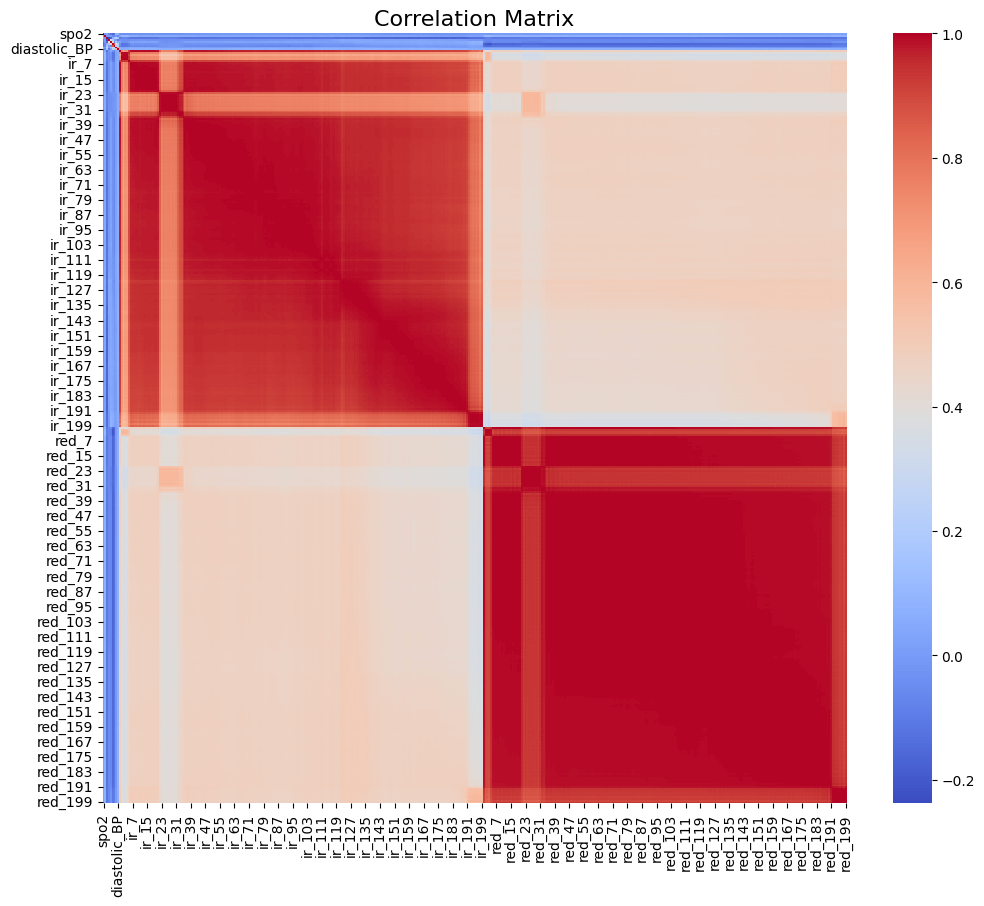

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [ ]:
features_df = pd.read_csv("/content/features.csv")
labels_df = pd.read_csv("/content/labels.csv")

# Assuming the rows in both dataframes correspond to the same samples,
# you can concatenate them column-wise.
combined_df = pd.concat([features_df, labels_df], axis=1)

print("Combined DataFrame shape:", combined_df.shape)
display(combined_df.head())

Combined DataFrame shape: (264, 37)


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56,52712.770458,...,0.0,44,Male,180.0,98,30.246914,107,100,122,83
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55,55092.154130,...,0.0,30,Female,154.0,43,18.131219,125,100,102,68
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54,61369.849652,...,0.0,61,Female,144.0,62,29.899691,93,100,141,93
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41,60349.452409,...,0.0,45,Male,172.0,103,34.816117,71,98,139,96
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51,60724.343618,...,0.0,23,Male,172.0,88,29.745809,166,98,112,75


In [ ]:
# Using mapping for userGender
combined_df['userGender'] = combined_df['userGender'].map({'Female': 0, 'Male': 1})

# Alternatively, you can use LabelEncoder (if you have more categories)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
combined_df['userGender'] = le.fit_transform(combined_df['userGender'])

# Display the first few rows of the updated DataFrame to see the encoded column
display(combined_df.head())

# Verify the data types again to ensure 'userGender' is no longer an object type
print("\nData types after one-hot encoding:")
print(combined_df.dtypes)

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
0,52577.426036,52672.286147,494.408818,51214.295208,53481.287901,2266.992693,-0.679211,-0.234299,56,52712.770458,...,0.0,44,1,180.0,98,30.246914,107,100,122,83
1,54981.852941,55090.747907,331.865852,52820.784885,55337.866131,2517.081246,-3.197905,13.477465,55,55092.154130,...,0.0,30,0,154.0,43,18.131219,125,100,102,68
2,61247.928994,61100.751013,344.706523,60731.276101,61941.177431,1209.901330,0.327449,-1.373854,54,61369.849652,...,0.0,61,0,144.0,62,29.899691,93,100,141,93
3,60305.934911,60340.486227,213.482900,59800.345442,60683.493785,883.148344,-0.406957,-0.882666,41,60349.452409,...,0.0,45,1,172.0,103,34.816117,71,98,139,96
4,60658.988235,60527.884581,324.515476,60259.382240,61786.899002,1527.516763,1.459666,1.720295,51,60724.343618,...,0.0,23,1,172.0,88,29.745809,166,98,112,75



Data types after one-hot encoding:
ir_mean                    float64
ir_median                  float64
ir_std                     float64
ir_min                     float64
ir_max                     float64
ir_range                   float64
ir_skewness                float64
ir_kurtosis                float64
ir_num_peaks                 int64
ir_mean_peak_amplitude     float64
ir_dominant_freq           float64
ir_total_energy            float64
ir_low_freq_band           float64
ir_high_freq_band          float64
red_mean                   float64
red_median                 float64
red_std                    float64
red_min                    float64
red_max                    float64
red_range                  float64
red_skewness               float64
red_kurtosis               float64
red_num_peaks                int64
red_mean_peak_amplitude    float64
red_dominant_freq          float64
red_total_energy           float64
red_low_freq_band          float64
red_high_freq_band 

Correlation Matrix (first 5 rows and columns):


,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
ir_mean,1.000000,0.995053,-0.230859,0.620797,0.966701,-0.174075,-0.038856,-0.026928,0.064314,0.999444,...,NaN,-0.135966,-0.031025,0.028799,-0.008478,-0.035820,0.039595,-0.017284,0.021459,0.071165
ir_median,0.995053,1.000000,-0.149663,0.562379,0.975396,-0.102157,-0.090983,0.000484,0.086370,0.996889,...,NaN,-0.133976,-0.040714,0.029875,-0.019718,-0.049574,0.041086,-0.009742,0.022611,0.061706
ir_std,-0.230859,-0.149663,1.000000,-0.850560,-0.041813,0.953273,-0.487729,0.435110,0.185704,-0.204209,...,NaN,0.048159,-0.064351,0.012452,-0.028711,-0.037889,-0.091399,0.077317,0.045874,-0.003505
ir_min,0.620797,0.562379,-0.850560,1.000000,0.491385,-0.874329,0.450722,-0.507051,-0.178821,0.600715,...,NaN,-0.074052,0.030935,-0.010045,-0.021446,-0.018485,0.112833,-0.049773,0.003297,0.039051
ir_max,0.966701,0.975396,-0.041813,0.491385,1.000000,-0.006933,-0.076986,0.030127,0.052193,0.971139,...,NaN,-0.115558,-0.045629,0.017196,-0.022340,-0.041734,0.020285,0.006876,0.037628,0.073652


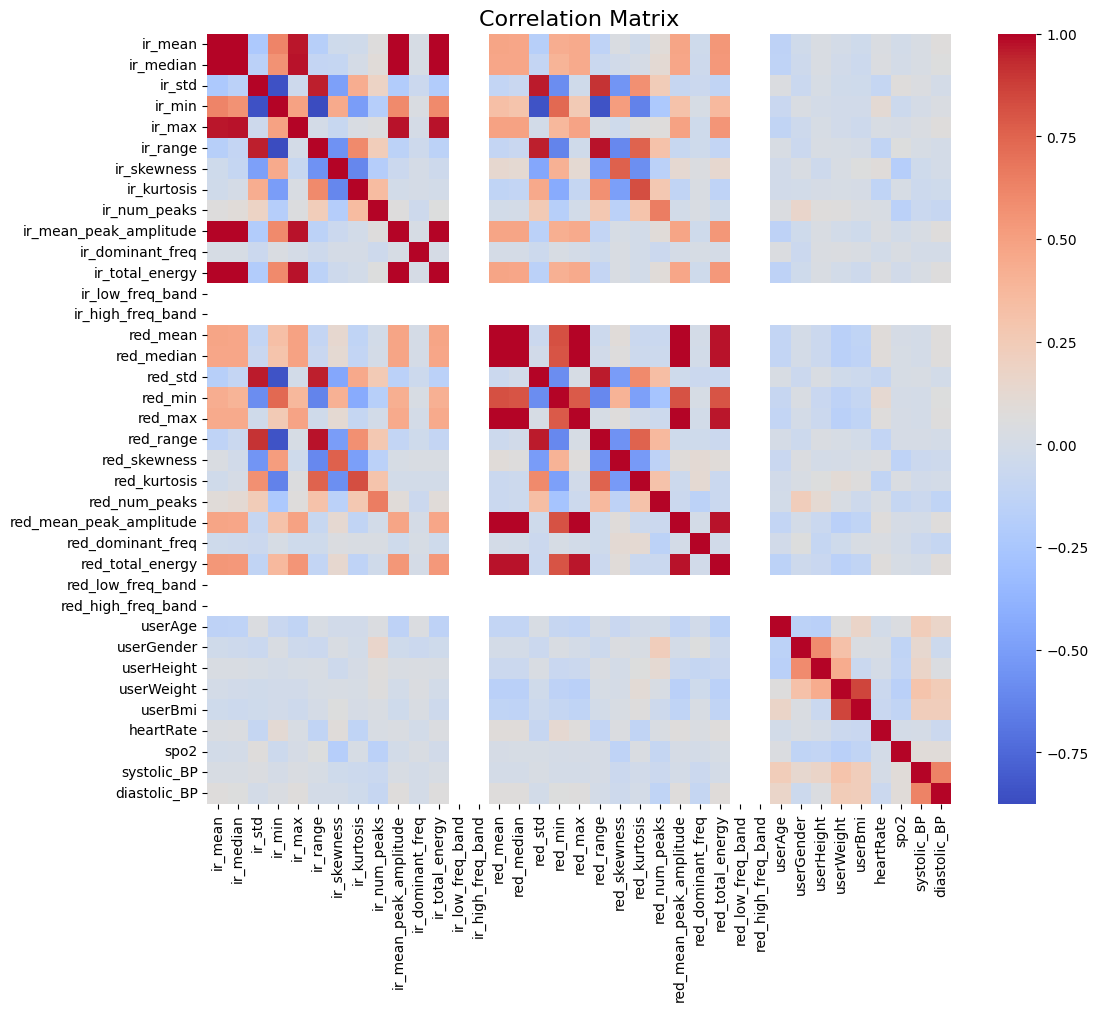

In [ ]:
# Find the correlation matrix
correlation_matrix_feature = combined_df.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix_feature.head())

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_feature, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=16)
plt.show()

In [ ]:
combined_df.isnull()

,ir_mean,ir_median,ir_std,ir_min,ir_max,ir_range,ir_skewness,ir_kurtosis,ir_num_peaks,ir_mean_peak_amplitude,...,red_high_freq_band,userAge,userGender,userHeight,userWeight,userBmi,heartRate,spo2,systolic_BP,diastolic_BP
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
260,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
261,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
262,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
combined_df.isnull().sum()

,0
ir_mean,0
ir_median,0
ir_std,0
ir_min,0
ir_max,0
ir_range,0
ir_skewness,0
ir_kurtosis,0
ir_num_peaks,0
ir_mean_peak_amplitude,0
